# Transit Anomaly Detection for Airport and Border Control Data

**Machine Learning Project — Academic Year 2025/26**
**Company brief:** Whitehall Reply — Project 2 *(Classical vs Multi-Agent anomaly detection)*

**Team members**    - Giulio D'Amico    - Alexis Mitracos
---

## Project scope

Border-control authorities and airport operators handle large volumes of passenger transits daily, with rich metadata attached to each event (timestamp, gate, route, nationality, document type, control outcome, alert flags). Today, anomaly detection on such data is mostly reactive. The goal of this project is to implement the same anomaly-detection system twice — once as a **classical pipeline** and once as a **multi-agent architecture** — and to produce a comparative analysis identifying the operational conditions under which each approach is preferable.

## Notebook Index

1. Setup and data loading
2. Data-quality audit
3. Univariate analysis
4. Bivariate analysis
5. Multivariate analysis
6. Outlier analysis
7. Cross-dataset coverage
8. Feature engineering
9. Engineered features
10. Feature selection
11. Isolation Forest detector
12. Local Outlier Factor detector
13. Z-score detector and three-way consensus
14. Rule-based post-processing layer
15. Conclusions and next steps


## 1. Setup and data loading

### 1.1 Imports and plotting defaults

We load the scientific stack (`numpy`, `pandas`, `matplotlib`, `seaborn`), `missingno` for missing-value diagnostics, `pycountry` for ISO country-code normalisation, and `re` for the regex-based date parsing used in the cleaning block. Plotting defaults are set globally so that every figure in the notebook shares the same style.


In [432]:
import warnings, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import pycountry

from IPython.display import display

# Global plotting defaults
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

# Project palette
NAVY, STEEL, CORAL, GREEN = "#1A3764", "#4682B4", "#E8735A", "#27AE60"
PALETTE = [NAVY, STEEL, CORAL, GREEN, "#F4A261", "#2A9D8F", "#E76F51"]

# Reproducibility
RANDOM_STATE = 42

### 1.2 Reference mappings

The raw CSVs come in Italian, with inconsistent casing, typographic errors (e.g. `AREOPORTO`), and a mixture of Italianised and English spellings for countries, cities and airports. To feed the downstream pipeline with a clean English `snake_case` schema we rely on four curated dictionaries:

- `manual_mapping` — IT to EN column-name mapping; disambiguates duplicated columns (e.g. `Tipo_Documento` and `TIPO_DOCUMENTO` become `document_type` and `document_type2`) that are reconciled in section 2.3.
- `it_to_en` — Italian to English country names; consumed by `pycountry` to emit the ISO alpha-3 code of every departure country. Kosovo, which has no official ISO code, is hand-coded as `RKS`.
- `city_mapping` — Italianised city names mapped to their canonical English spelling.
- `iata_mapping` — a curated `IATA -> {city, airport}` lookup, used to back-fill missing city and airport descriptions in the Alarms dataset when the IATA column is populated but the free-text fields are not.

All four dictionaries are embedded in the notebook (rather than imported from a configuration module) so that the notebook is fully self-contained, as required by the submission guidelines.


In [433]:
it_to_en = {
    'Albania': 'Albania', 'Algeria': 'Algeria', 'Antigua e barbuda': 'Antigua and Barbuda',
    'Arabia saudita': 'Saudi Arabia', 'Argentina': 'Argentina', 'Armenia': 'Armenia',
    'Azerbaigian': 'Azerbaijan', 'Bahrain': 'Bahrain', 'Brasile': 'Brazil',
    'Canada': 'Canada', 'Capo verde': 'Cabo Verde', 'Cina': 'China',
    'Corea del sud': 'Korea, Republic of', 'Cossovo': 'Kosovo', 'Egitto': 'Egypt',
    'Emirati arabi uniti': 'United Arab Emirates', 'Etiopia': 'Ethiopia',
    'Georgia': 'Georgia', 'Giamaica': 'Jamaica', 'Giappone': 'Japan',
    'Giordania': 'Jordan', 'Hong kong': 'Hong Kong', 'India': 'India',
    'Iran': 'Iran, Islamic Republic of', 'Israele': 'Israel', 'Kazakistan': 'Kazakhstan',
    'Kenya': 'Kenya', 'Kuwait': 'Kuwait', 'Libano': 'Lebanon', 'Libia': 'Libya',
    'Macedonia': 'North Macedonia', 'Maldive': 'Maldives', 'Marocco': 'Morocco',
    'Mauritius': 'Mauritius', 'Messico': 'Mexico', 'Moldavia': 'Moldova, Republic of',
    'Montenegro': 'Montenegro', 'Oman': 'Oman', 'Qatar': 'Qatar',
    'Regno unito': 'United Kingdom', 'Repubblica dominicana': 'Dominican Republic',
    'Senegal': 'Senegal', 'Serbia': 'Serbia', 'Singapore': 'Singapore',
    'Stati uniti': 'United States', 'Taiwan': 'Taiwan, Province of China',
    'Tanzania': 'Tanzania, United Republic of', 'Tunisia': 'Tunisia',
    'Turchia': 'Turkey', 'Uzbekistan': 'Uzbekistan'
}
city_mapping = {
    'Algeri': 'Algiers', 'Belgrado': 'Belgrade', 'Citta Del Messico': 'Mexico City',
    'Filadelfia': 'Philadelphia', 'Londra': 'London', 'Nuova Delhi': 'New Delhi',
    'Pechino': 'Beijing', 'San Paolo': 'Sao Paulo', 'Skopie': 'Skopje',
    'Smirne': 'Izmir', 'Tel Aviv Yafo': 'Tel Aviv', "St. John'S": "St. John's",
    'Buenos Aires': 'Buenos Aires', 'Rio De Janeiro': 'Rio de Janeiro',
    'Abu Dhabi': 'Abu Dhabi', 'Addis Ababa': 'Addis Ababa', 'Hong Kong': 'Hong Kong',
    'Kuwait City': 'Kuwait City', 'Los Angeles': 'Los Angeles', 'New York': 'New York'
}
iata_mapping = {
    'AUH': {'city': 'Abu Dhabi', 'airport': 'Abu Dhabi International'},
    'ADD': {'city': 'Addis Ababa', 'airport': 'Bole International'},
    'AGA': {'city': 'Agadir', 'airport': 'Agadir Al Massira'},
    'ALG': {'city': 'Algiers', 'airport': 'Houari Boumediene'},
    'ALA': {'city': 'Almaty', 'airport': 'Almaty International'},
    'AMM': {'city': 'Amman', 'airport': 'Queen Alia International'},
    'ANU': {'city': "St. John's", 'airport': 'V.C. Bird International'},
    'ATL': {'city': 'Atlanta', 'airport': 'Hartsfield-Jackson Atlanta International'},
    'ATQ': {'city': 'Amritsar', 'airport': 'Sri Guru Ram Dass Jee International'},
    'BAH': {'city': 'Manama', 'airport': 'Bahrain International'},
    'BEG': {'city': 'Belgrade', 'airport': 'Nikola Tesla'},
    'BEY': {'city': 'Beirut', 'airport': 'Beirut-Rafic Hariri International'},
    'BFS': {'city': 'Belfast', 'airport': 'Belfast International'},
    'BHX': {'city': 'Birmingham', 'airport': 'Birmingham International'},
    'BOS': {'city': 'Boston', 'airport': 'Logan International'},
    'BRS': {'city': 'Bristol', 'airport': 'Bristol Airport'},
    'CAI': {'city': 'Cairo', 'airport': 'Cairo International'},
    'CAN': {'city': 'Guangzhou', 'airport': 'Guangzhou Baiyun International'},
    'CGO': {'city': 'Zhengzhou', 'airport': 'Zhengzhou Xinzheng International'},
    'CKG': {'city': 'Chongqing', 'airport': 'Chongqing Jiangbei International'},
    'CMN': {'city': 'Casablanca', 'airport': 'Mohammed V International'},
    'CUN': {'city': 'Cancun', 'airport': 'Cancun International'},
    'DEL': {'city': 'New Delhi', 'airport': 'Indira Gandhi International'},
    'DFW': {'city': 'Dallas-Fort Worth', 'airport': 'Dallas/Fort Worth International'},
    'DMM': {'city': 'Dammam', 'airport': 'King Fahd International'},
    'DOH': {'city': 'Doha', 'airport': 'Hamad International'},
    'DSS': {'city': 'Dakar', 'airport': 'Blaise Diagne International'},
    'DWC': {'city': 'Dubai', 'airport': 'Al Maktoum International'},
    'DXB': {'city': 'Dubai', 'airport': 'Dubai International'},
    'EDI': {'city': 'Edinburgh', 'airport': 'Edinburgh Airport'},
    'EVN': {'city': 'Yerevan', 'airport': 'Zvartnots International'},
    'EWR': {'city': 'Newark', 'airport': 'Newark Liberty International'},
    'EZE': {'city': 'Buenos Aires', 'airport': 'Ezeiza Ministro Pistarini'},
    'FAB': {'city': 'Farnborough', 'airport': 'Farnborough Airport'},
    'FEZ': {'city': 'Fes', 'airport': 'Fes-Saiss'},
    'GIG': {'city': 'Rio de Janeiro', 'airport': 'Galeao-Antonio Carlos Jobim International'},
    'GLA': {'city': 'Glasgow', 'airport': 'Glasgow International'},
    'GRU': {'city': 'Sao Paulo', 'airport': 'Sao Paulo/Guarulhos International'},
    'GYD': {'city': 'Baku', 'airport': 'Heydar Aliyev International'},
    'HGH': {'city': 'Hangzhou', 'airport': 'Hangzhou Xiaoshan International'},
    'HKG': {'city': 'Hong Kong', 'airport': 'Hong Kong International'},
    'HND': {'city': 'Tokyo', 'airport': 'Tokyo Haneda International'},
    'HRG': {'city': 'Hurghada', 'airport': 'Hurghada International'},
    'IAD': {'city': 'Washington', 'airport': 'Washington Dulles International'},
    'ICN': {'city': 'Seoul', 'airport': 'Incheon International'},
    'IKA': {'city': 'Tehran', 'airport': 'Imam Khomeini International'},
    'IST': {'city': 'Istanbul', 'airport': 'Istanbul Airport'},
    'JED': {'city': 'Jeddah', 'airport': 'King Abdulaziz International'},
    'JFK': {'city': 'New York', 'airport': 'John F. Kennedy International'},
    'KIV': {'city': 'Chisinau', 'airport': 'Chisinau International'},
    'KUT': {'city': 'Kutaisi', 'airport': 'Kutaisi International'},
    'KWI': {'city': 'Kuwait City', 'airport': 'Kuwait International'},
    'LAX': {'city': 'Los Angeles', 'airport': 'Los Angeles International'},
    'LBA': {'city': 'Leeds', 'airport': 'Leeds Bradford'},
    'LCY': {'city': 'London', 'airport': 'London City'},
    'LGW': {'city': 'London', 'airport': 'London Gatwick'},
    'LHR': {'city': 'London', 'airport': 'London Heathrow'},
    'LPL': {'city': 'Liverpool', 'airport': 'Liverpool John Lennon'},
    'LRM': {'city': 'La Romana', 'airport': 'La Romana International'},
    'LTN': {'city': 'London', 'airport': 'London Luton'},
    'LXR': {'city': 'Luxor', 'airport': 'Luxor International'},
    'MAN': {'city': 'Manchester', 'airport': 'Manchester Airport'},
    'MBA': {'city': 'Mombasa', 'airport': 'Moi International'},
    'MBJ': {'city': 'Montego Bay', 'airport': 'Sangster International'},
    'MCT': {'city': 'Muscat', 'airport': 'Muscat International'},
    'MEX': {'city': 'Mexico City', 'airport': 'Benito Juarez International'},
    'MIA': {'city': 'Miami', 'airport': 'Miami International'},
    'MLE': {'city': 'Male', 'airport': 'Velana International'},
    'MRU': {'city': 'Plaisance', 'airport': 'Sir Seewoosagur Ramgoolam International'},
    'NCL': {'city': 'Newcastle', 'airport': 'Newcastle Airport'},
    'NKG': {'city': 'Nanjing', 'airport': 'Nanjing Lukou International'},
    'OAK': {'city': 'Oakland', 'airport': 'Oakland International'},
    'OXF': {'city': 'Oxford', 'airport': 'London Oxford'},
    'PEK': {'city': 'Beijing', 'airport': 'Beijing Capital International'},
    'PHL': {'city': 'Philadelphia', 'airport': 'Philadelphia International'},
    'PRN': {'city': 'Pristina', 'airport': 'Prishtina International'},
    'PVG': {'city': 'Shanghai', 'airport': 'Shanghai Pudong International'},
    'RAK': {'city': 'Marrakech', 'airport': 'Menara'},
    'RBA': {'city': 'Rabat', 'airport': 'Rabat-Sale'},
    'RMO': {'city': 'Chisinau', 'airport': 'Chisinau International'},
    'RUH': {'city': 'Riyadh', 'airport': 'King Khaled International'},
    'SAW': {'city': 'Istanbul', 'airport': 'Sabiha Gokcen'},
    'SHJ': {'city': 'Sharjah', 'airport': 'Sharjah International'},
    'SID': {'city': 'Sal', 'airport': 'Amilcar Cabral International'},
    'SIN': {'city': 'Singapore', 'airport': 'Changi'},
    'SKP': {'city': 'Skopje', 'airport': 'Skopje International'},
    'SLL': {'city': 'Salalah', 'airport': 'Salalah Airport'},
    'SSH': {'city': 'Sharm El Sheikh', 'airport': 'Sharm El-Sheikh International'},
    'STN': {'city': 'London', 'airport': 'London Stansted'},
    'SZX': {'city': 'Shenzhen', 'airport': 'Shenzhen Baoan International'},
    'TAS': {'city': 'Tashkent', 'airport': 'Tashkent International'},
    'TBS': {'city': 'Tbilisi', 'airport': 'Tbilisi International'},
    'TGD': {'city': 'Podgorica', 'airport': 'Podgorica Airport'},
    'TIA': {'city': 'Tirana', 'airport': 'Rinas Mother Teresa'},
    'TLV': {'city': 'Tel Aviv', 'airport': 'Ben Gurion International'},
    'TNG': {'city': 'Tangier', 'airport': 'Ibn Battouta'},
    'TPE': {'city': 'Taipei', 'airport': 'Taiwan Taoyuan International'},
    'TUN': {'city': 'Tunis', 'airport': 'Tunis-Carthage'},
    'WNZ': {'city': 'Wenzhou', 'airport': 'Wenzhou Longwan International'},
    'YUL': {'city': 'Montreal', 'airport': 'Montreal-Trudeau International'},
    'YYZ': {'city': 'Toronto', 'airport': 'Toronto Pearson International'},
    'ZNZ': {'city': 'Zanzibar', 'airport': 'Abeid Amani Karume International'},
}
manual_mapping = {
    "OCCORRENZE": "occurrences",
    "AREOPORTO_ARRIVO": "arrival_airport_iata",
    "AREOPORTO_PARTENZA": "departure_airport_iata",
    "ANNO_PARTENZA": "departure_year",
    "MESE_PARTENZA": "departure_month",
    "DATA_PARTENZA": "departure_date",
    "DESCR_AEREOPORTO_ARR": "arrival_airport_description",
    "DESCR_AEREOPORTO_PART": "departure_airport_description",
    "CITTA_ARR": "arrival_city",
    "CITTA_PARTENZA": "departure_city",
    "CODICE_PAESE_ARR": "arrival_country_code",
    "CODICE_PAESE_PART": "departure_country_code",
    "PAESE_ARR": "arrival_country",
    "PAESE_PART": "departure_country",
    "ZONA": "zone",
    "TOT": "total",
    "MOTIVO_ALLARME": "alarm_reason",
    "note_operatore": "operator_notes",
    "flag_rischio": "risk_flag",
    "Paese Partenza": "departure_country_full",
    "CODICE PAESE ARR": "arrival_country_code_full",
    "3zona": "zone_3",
    "paese%arr": "arrival_country_percentage",
    "tot voli": "total_flights",
    "NAZIONALITA": "nationality",
    "GIORNO_PARTENZA": "departure_day",
    "ENTRATI": "entries",
    "INVESTIGATI": "investigated",
    "ALLARMATI": "alarms",
    "TIPO_DOCUMENTO": "document_type",
    "GENERE": "gender",
    "FASCIA_ETA": "age_group",
    "FLAG_TRANSITO": "transit_flag",
    "COMPAGNIA_AEREA": "airline",
    "NUMERO_VOLO": "flight_number",
    "ESITO_CONTROLLO": "control_outcome",
    "codice_rischio": "risk_code",
    "Tipo_Documento": "document_type2",
    "Tipo Documento": "document_type2",
    "FASCIA_ETA2": "age_group2",
    "FASCIA ETA": "age_group2",
    "3nazionalita": "nationality_3",
    "compagnia%aerea": "airline%",
    "num volo": "flight number",
}

### 1.3 Load raw CSVs

We read both CSVs and apply the IT-to-EN column rename in a single step. We keep two separate DataFrames (`df_alarms`, `df_travelers`) because they describe two different observation units — alarm events vs. traveler-category daily aggregates — and share only a subset of columns.


In [434]:
df_alarms    = pd.read_csv("ALLARMI.csv")
df_travelers = pd.read_csv("TIPOLOGIA_VIAGGIATORE.csv")

df_alarms    = df_alarms.rename(columns=manual_mapping)
df_travelers = df_travelers.rename(columns=manual_mapping)

print(f"Loaded Alarms    : {df_alarms.shape[0]:,} rows x {df_alarms.shape[1]} columns")
print(f"Loaded Travelers : {df_travelers.shape[0]:,} rows x {df_travelers.shape[1]} columns")

Loaded Alarms    : 5,080 rows x 24 columns
Loaded Travelers : 5,095 rows x 33 columns


## 2. Data-quality audit

### 2.1 Raw dataset inspection

Before any cleaning we profile both datasets: shape, column dtypes, per-column missingness (count and percentage), and cardinality. A snapshot of the raw missing counts and of the raw column set is stored in memory so that section 2.8 can produce a rigorous before/after comparison.


In [435]:
def inspect_dataset(df, dataset_name):
    """Print shape, dtype, missing count, missing %, and cardinality for each column."""
    print(f"\n{'='*60}\n  {dataset_name}\n{'='*60}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
    overview = pd.DataFrame({
        "Dtype":       df.dtypes,
        "Missing":     df.isnull().sum(),
        "Missing %":   (df.isnull().sum() / len(df) * 100).round(2),
        "Cardinality": df.nunique(),
    })
    print("Column-level overview:")
    display(overview)

inspect_dataset(df_alarms,    "ALARMS (ALLARMI)")
inspect_dataset(df_travelers, "TRAVELERS (TIPOLOGIA_VIAGGIATORE)")


  ALARMS (ALLARMI)
Shape: 5,080 rows x 24 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
occurrences,object,0,0.00,30
arrival_airport_iata,object,0,0.00,77
departure_airport_iata,object,0,0.00,208
departure_year,object,0,0.00,5
departure_month,object,0,0.00,14
departure_date,object,0,0.00,3810
arrival_airport_description,object,0,0.00,31
departure_airport_description,object,109,2.15,136
arrival_city,object,0,0.00,29
departure_city,object,101,1.99,110



  TRAVELERS (TIPOLOGIA_VIAGGIATORE)
Shape: 5,095 rows x 33 columns

Column-level overview:


,Dtype,Missing,Missing %,Cardinality
nationality,object,116,2.28,19
arrival_airport_iata,object,0,0.00,79
departure_airport_iata,object,0,0.00,242
departure_year,object,0,0.00,4
departure_month,object,0,0.00,5
departure_day,int64,0,0.00,31
departure_date,object,0,0.00,3977
arrival_airport_description,object,0,0.00,29
departure_airport_description,object,0,0.00,176
arrival_city,object,0,0.00,27


The two missingness bar-charts below provide a visual snapshot of data completeness *before* cleaning. Longer bars indicate more complete columns; short ones flag fields that will require imputation or domain-specific treatment downstream.


Missingness bar-chart (BEFORE cleaning) — Alarms


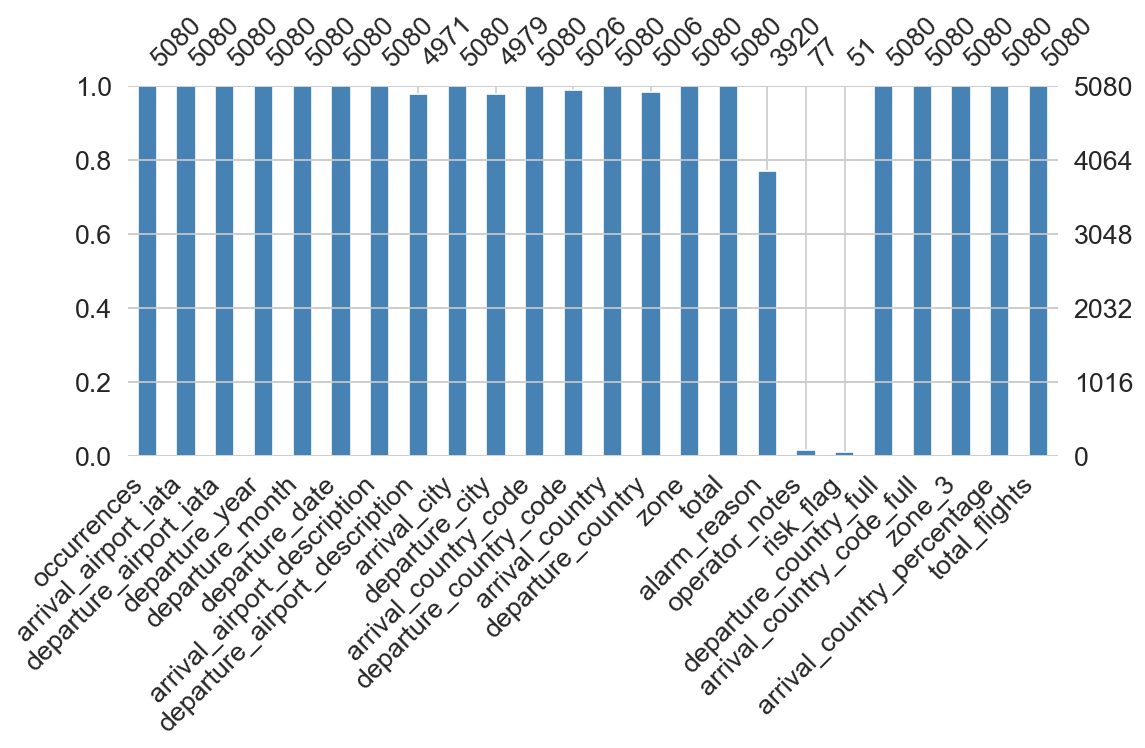

Missingness bar-chart (BEFORE cleaning) — Travelers


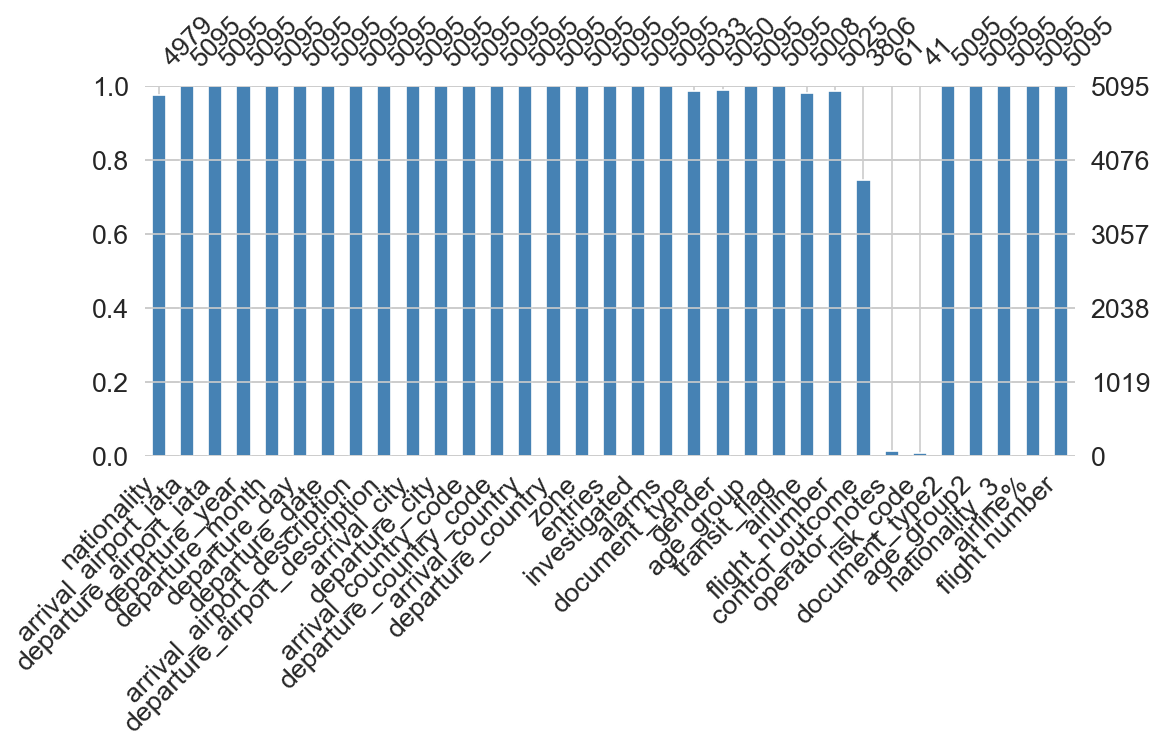

In [436]:
print("Missingness bar-chart (BEFORE cleaning) — Alarms")
msno.bar(df_alarms, figsize=(10, 4), color=STEEL)
plt.show()

print("Missingness bar-chart (BEFORE cleaning) — Travelers")
msno.bar(df_travelers, figsize=(10, 4), color=STEEL)
plt.show()

# Snapshot raw state so section 2.8 can produce a before/after audit.
raw_missing_alarms    = df_alarms.isnull().sum().copy()
raw_missing_travelers = df_travelers.isnull().sum().copy()
raw_shape_alarms      = df_alarms.shape
raw_shape_travelers   = df_travelers.shape

### 2.2 Categorical-cardinality inspection

We split categorical columns into two buckets: *low-cardinality* (≤ 400 unique values, amenable to visual inspection and rule-based cleanup) and *high-cardinality* (> 400, which will require grouping or encoding). We plot only the first group so the chart stays readable, and print the high-cardinality columns as an early warning. Cardinality > 15 is also flagged in coral as a soft threshold for downstream one-hot encoding.

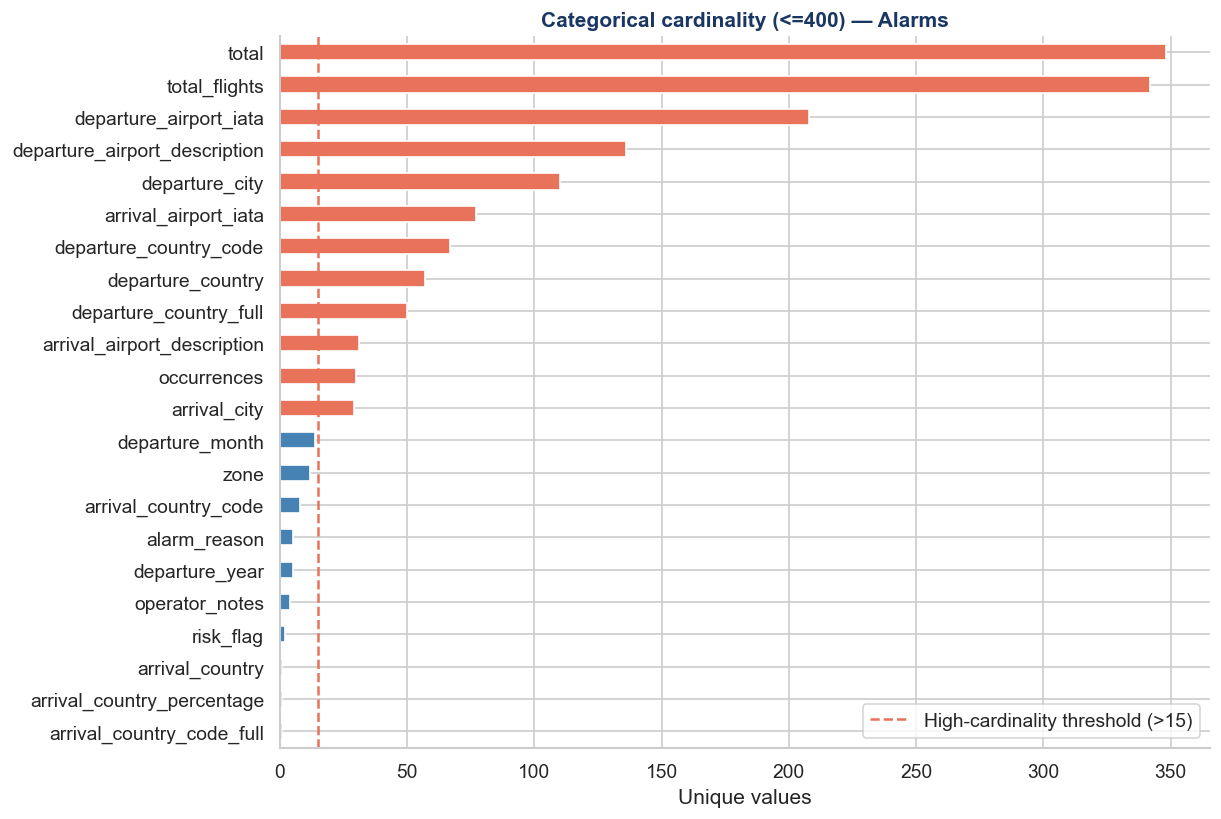

HIGH-CARDINALITY features (excluded from chart):
    'departure_date': 3810 unique values — needs grouping/target encoding

  Reviewing unique values (Alarms):
  'arrival_country_code_full' (1 values): ['ITA']

  'arrival_country_percentage' (1 values): ['Italia']

  'arrival_country' (1 values): ['Italia']

  'risk_flag' (2 values): ['ALTO', 'MEDIO']

  'operator_notes' (4 values): ['Alert manuale', 'Doppio controllo', 'Passeggero noto', 'Verifica richiesta']

  'departure_year' (5 values): ['2023', '2024', '2024.', '24', 'anno 2024']

  'alarm_reason' (5 values): ['INTERPOL', 'Manuale', 'NSIS', 'SDI', 'TSC']

  'arrival_country_code' (8 values): ['DEU', 'ESP', 'FRA', 'GB', 'GBR', 'IT', 'ITA', 'TUR']

  'zone' (12 values): ['-1', '1', '10', '2', '4', '5', '6', '7', '8', '9', '99', '??']

  'departure_month' (14 values): ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', 'FEB', 'GEN']

  'arrival_city' (29 values): ['Ancona', 'Bari', 'Bergamo', 'Bologna', 'Bolzano

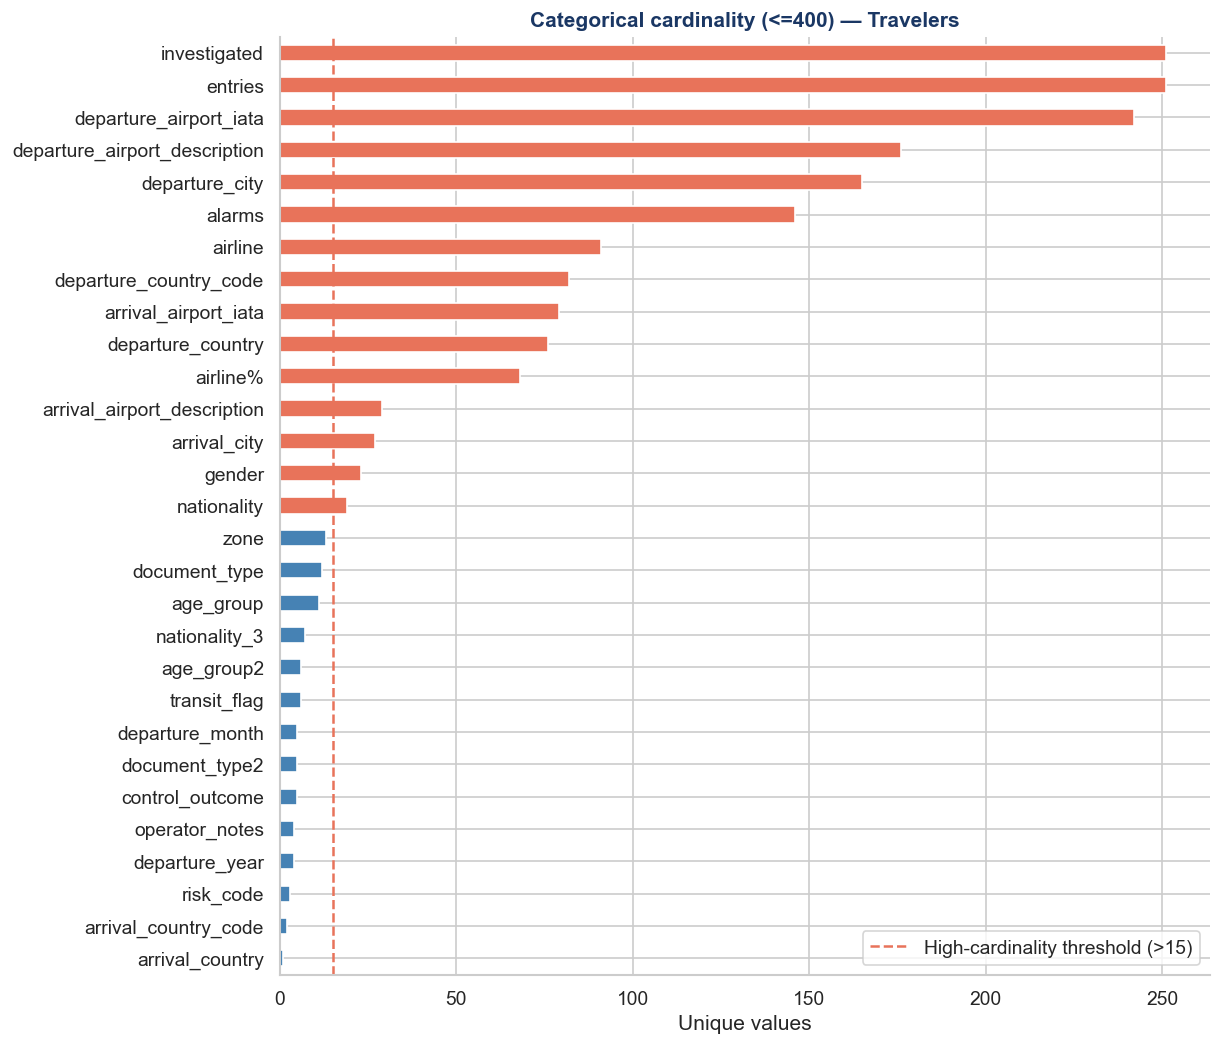

HIGH-CARDINALITY features (excluded from chart):
    'flight_number': 701 unique values — needs grouping/target encoding
    'flight number': 706 unique values — needs grouping/target encoding
    'departure_date': 3977 unique values — needs grouping/target encoding

  Reviewing unique values (Travelers):
  'arrival_country' (1 values): ['Italia']

  'arrival_country_code' (2 values): ['IT', 'ITA']

  'risk_code' (3 values): ['R1', 'R2', 'R3']

  'departure_year' (4 values): ['2023', '2024', '24', 'anno 2024']

  'operator_notes' (4 values): ['Alert manuale', 'Passeggero noto', 'Segnalazione esterna', 'Verifica richiesta']

  'control_outcome' (5 values): ['FERMATO', 'IN ATTESA', 'OK', 'RESPINTO', 'SEGNALATO']

  'document_type2' (5 values): ["Carta d'identità", 'N.D.', 'Passaporto', 'Permesso di soggiorno', 'Visto']

  'departure_month' (5 values): ['01', '02', '12', 'FEB', 'GEN']

  'transit_flag' (6 values): ['Multitratta', 'N/C', 'Singola Tratta', 'TRANSITO', 'Tripla Tratta', 'sing

In [437]:
def inspect_categorical(df, dataset_name):
    """Separate low- and high-cardinality categoricals, plot the former, list the latter."""
    cat_cols = df.select_dtypes(include=["object"]).columns
    if len(cat_cols) == 0:
        print(f"  No categorical columns in {dataset_name}.")
        return

    card = df[cat_cols].nunique().sort_values(ascending=True)
    card_low, card_high = card[card <= 400], card[card > 400]

    if not card_low.empty:
        plt.figure(figsize=(10, max(4, len(card_low) * 0.35)))
        colors = [CORAL if v > 15 else STEEL for v in card_low]
        card_low.plot(kind="barh", color=colors, edgecolor="white")
        plt.axvline(15, color=CORAL, ls="--", lw=1.5,
                    label="High-cardinality threshold (>15)")
        plt.title(f"Categorical cardinality (<=400) — {dataset_name}",
                  fontweight="bold", color=NAVY)
        plt.xlabel("Unique values"); plt.legend(); sns.despine()
        plt.show()

    if not card_high.empty:
        print("HIGH-CARDINALITY features (excluded from chart):")
        for col, val in card_high.items():
            print(f"    '{col}': {val} unique values — needs grouping/target encoding")
        print()

    print(f"  Reviewing unique values ({dataset_name}):")
    for col in card_low.index:
        uv = sorted(df[col].dropna().astype(str).unique())
        print(f"  '{col}' ({len(uv)} values): {uv}\n")

inspect_categorical(df_alarms,    "Alarms")
inspect_categorical(df_travelers, "Travelers")

### 2.3 Redundant-column resolution (Travelers)

The Travelers dataset ships with duplicated columns that encode the same logical field under different formats (e.g. `document_type` vs `document_type2`, `flight_number` vs `flight number`, `nationality` vs `nationality_3`). For each pair we:

1. quantify how many rows conflict (both non-null but different after normalisation);
2. use the more complete/normalised source column as the primary value, falling back to the legacy column only when the source is missing;
3. drop the redundant source column once merged into the canonical column name.

The canonical column name is kept for downstream compatibility, but conflicting values are resolved in favour of the complete source field rather than accidentally discarding it.

In [438]:
redundant_pairs = [
    ("document_type2",  "document_type"),
    ("age_group2",      "age_group"),
    ("nationality_3",    "nationality"),
    ("airline%",        "airline"),
    ("flight number",  "flight_number"),
]
def _norm(s): return s.astype(str).str.strip().str.upper()

for canonical_col, source_col in redundant_pairs:
    if canonical_col not in df_travelers.columns or source_col not in df_travelers.columns:
        print(f"Column pair missing: '{canonical_col}' & '{source_col}' — skipped")
        continue
    s_canonical, s_source = df_travelers[canonical_col], df_travelers[source_col]
    mask_conflict = (s_canonical.notna() & s_source.notna()
                     & (_norm(s_canonical) != _norm(s_source)))
    n_conflicts   = mask_conflict.sum()
    n_overwritten = (s_source.notna() & (s_canonical.isna() | mask_conflict)).sum()
    conflict_preview = df_travelers.loc[mask_conflict, [canonical_col, source_col]].head(3).copy()
    df_travelers[canonical_col] = s_source.combine_first(s_canonical)
    print(f"'{canonical_col}' <- primary values from '{source_col}'  "
          f"| {n_overwritten} values sourced | {n_conflicts} conflicts resolved from source")
    if n_conflicts > 0:
        display(conflict_preview)

cols_to_drop = [c for _, c in redundant_pairs if c in df_travelers.columns]
df_travelers.drop(columns=cols_to_drop, inplace=True)
print(f"\nDropped redundant columns: {cols_to_drop}")
print(f"Travelers now has {df_travelers.shape[1]} columns (was {raw_shape_travelers[1]}).")

'document_type2' <- primary values from 'document_type'  | 136 values sourced | 136 conflicts resolved from source


,document_type2,document_type
18,Permesso di soggiorno,?
61,Permesso di soggiorno,?
155,N.D.,?


'age_group2' <- primary values from 'age_group'  | 8 values sourced | 8 conflicts resolved from source


,age_group2,age_group
980,0-17,N/C
1573,0-17,minore
2701,N.D.,-5


'nationality_3' <- primary values from 'nationality'  | 205 values sourced | 205 conflicts resolved from source


...

'airline%' <- primary values from 'airline'  | 180 values sourced | 180 conflicts resolved from source


,airline%,airline
26,Turkish Airlines,//
28,Ryanair DAC,?
51,Easyjet,-


'flight number' <- primary values from 'flight_number'  | 134 values sourced | 134 conflicts resolved from source


,flight number,flight_number
45,AA0198,
55,BA0604,
101,W43845,n.d.



Dropped redundant columns: ['document_type', 'age_group', 'nationality', 'airline', 'flight_number']
Travelers now has 28 columns (was 33).


### 2.4 Text standardisation & unknown-value unification (Travelers)

We perform three passes over every text column:

1. `strip + UPPERCASE` to collapse trivial casing/whitespace variants;
2. map all unknown tokens (`ND`, `UNKNOWN`, `N/A`, …) to the canonical `'N.D.'` so that they remain *informative categoricals* rather than fake NaNs;
3. convert *junk* tokens (`-`, `//`, `?`, `XX`, …) into proper `NaN` so that downstream imputation logic can see them.

In [439]:
text_cols = df_travelers.select_dtypes(include=["object"]).columns

for col in text_cols:
    df_travelers[col] = df_travelers[col].astype(str).str.strip().str.upper()

unknown_variants = ["ND", "UNKNOWN", "UNKN", "N/A", "N/C"]
df_travelers[text_cols] = df_travelers[text_cols].replace(unknown_variants, "N.D.")

junk_values = ["-", "//", "?", "???", "XX", "ZZ", "NAN", ""]
df_travelers[text_cols] = df_travelers[text_cols].replace(junk_values, np.nan)

print("Text standardised: UPPERCASE, unknown variants -> 'N.D.', junk tokens -> NaN.")
for col in ["departure_airport_iata", "arrival_airport_iata", "gender"]:
    if col in df_travelers.columns:
        print(f"  '{col}' unique: {sorted(df_travelers[col].dropna().unique())}")

Text standardised: UPPERCASE, unknown variants -> 'N.D.', junk tokens -> NaN.
  'departure_airport_iata' unique: ['ABJ', 'ADB', 'ADD', 'ADL', 'AER', 'AKL', 'ALA', 'ALG', 'AMD', 'AMM', 'ARN', 'ASB', 'ASM', 'ATL', 'AUH', 'AYT', 'BAH', 'BEG', 'BFS', 'BHX', 'BKK', 'BLR', 'BNA', 'BNE', 'BOG', 'BOS', 'BRS', 'BSB', 'BUF', 'CAI', 'CAN', 'CEB', 'CGK', 'CLE', 'CMN', 'CUN', 'CVG', 'DAR', 'DEL', 'DFW', 'DMM', 'DOH', 'DPS', 'DSS', 'DTW', 'DUR', 'DWC', 'DXB', 'EDI', 'ELQ', 'EMA', 'ESB', 'EVN', 'EWR', 'EZE', 'FEZ', 'FIH', 'FLL', 'FRA', 'FRU', 'FUK', 'GIG', 'GLA', 'GRU', 'GYD', 'GZT', 'HAN', 'HGH', 'HKG', 'HKT', 'HND', 'HRG', 'IAD', 'IAH', 'ICN', 'IFN', 'IKA', 'ISB', 'IST', 'JAX', 'JED', 'JFK', 'KBL', 'KCH', 'KIV', 'KUL', 'KUT', 'KWI', 'KZN', 'LAD', 'LAS', 'LAX', 'LCY', 'LGW', 'LHR', 'LOS', 'LPL', 'LRM', 'LTN', 'MAN', 'MBA', 'MCT', 'MED', 'MEL', 'MEX', 'MHD', 'MIA', 'MJI', 'MLE', 'MNL', 'MPM', 'MRU', 'MYR', 'NAV', 'NBO', 'NCL', 'NOS', 'NRT', 'NSI', 'ORD', 'OUA', 'OXB', 'PEK', 'PER', 'PEW', 'PHL', 'PKX

### 2.5 Numeric & domain-specific standardisation (Travelers)

Numeric columns in Travelers arrive mixed with unit suffixes (`PAX`), Italian decimal commas, and illegal sentinels. We handle them in four sub-steps.

**2.5.a** — Recode Italian 2-digit years and month abbreviations; align country codes (`IT` → `ITA`).  
**2.5.b** — `entries`, `investigated`, `alarms`: comma → dot, strip non-numeric, clip to plausible bounds `[0, 1000]`, cast to pandas nullable `Int64` (you cannot have 1.5 passengers).  
**2.5.c** — `zone`: clean to integer in `[0, 10]`.  
**2.5.d** — `gender`: collapse numeric codes (`1`/`2`), Italian (`MASCHIO`/`FEMMINA`), and English variants to canonical `M/F/X`.

In [440]:
# 2.5a — logical mapping
if "arrival_country_code" in df_travelers.columns:
    df_travelers["arrival_country_code"] = (
        df_travelers["arrival_country_code"].replace({"IT": "ITA"})
    )
if "departure_year" in df_travelers.columns:
    df_travelers["departure_year"] = df_travelers["departure_year"].replace(
        {"24": "2024", "ANNO 2024": "2024", "anno 2024": "2024"})

if "departure_month" in df_travelers.columns:
    df_travelers["departure_month"] = df_travelers["departure_month"].replace(
        {"GEN": "01", "FEB": "02"})

# 2.5b — numeric cleaning
quant_cols = ["entries", "investigated", "alarms"]
for col in quant_cols:
    if col not in df_travelers.columns: continue
    before_dtype, before_nulls = df_travelers[col].dtype, df_travelers[col].isna().sum()
    df_travelers[col] = df_travelers[col].astype(str).str.replace(" pax", "")
    df_travelers[col] = df_travelers[col].astype(str).str.replace(",", ".")
    df_travelers[col] = df_travelers[col].str.replace(r"[^\d.\-]", "", regex=True)
    df_travelers[col] = pd.to_numeric(df_travelers[col], errors="coerce")
    df_travelers.loc[(df_travelers[col] < 0) | (df_travelers[col] > 1000), col] = np.nan
    df_travelers[col] = df_travelers[col].astype("Int64")
    print(f"    {col}: dtype {before_dtype}→{df_travelers[col].dtype}"
          f"  |  NaN {before_nulls}→{df_travelers[col].isna().sum()}")

# 2.5c — zone
if "zone" in df_travelers.columns:
    df_travelers["zone"] = df_travelers["zone"].astype(str).str.strip()
    df_travelers["zone"] = df_travelers["zone"].replace(["??", "?", "-"], np.nan)
    df_travelers["zone"] = pd.to_numeric(df_travelers["zone"], errors="coerce")
    df_travelers.loc[(df_travelers["zone"] < 0) | (df_travelers["zone"] > 10), "zone"] = np.nan
    df_travelers["zone"] = df_travelers["zone"].astype("Int64")

# 2.5d — gender
if "gender" in df_travelers.columns:
    gender_map = {"1": "M", "MALE": "M", "MASCHIO": "M", "M": "M",
                  "2": "F", "FEMALE": "F", "FEMMINA": "F", "F": "F",
                  "N/B": "X", "X": "X","N.D.": "X"}
    df_travelers["gender"] = df_travelers["gender"].replace(gender_map)
    print(f"    gender normalised: {sorted(df_travelers['gender'].dropna().unique())}")

    entries: dtype object→Int64  |  NaN 40→91
    investigated: dtype object→Int64  |  NaN 33→91
    alarms: dtype object→Int64  |  NaN 33→79
    gender normalised: ['F', 'M', 'X']


### 2.6 Redundant-column resolution (Alarms)

The Alarms dataset contains two pairs of columns encoding the same logical field:

- `TOTAL` vs `TOTAL_FLIGHTS`: both count total flights; `TOTAL_FLIGHTS` is the canonical name.
- `ZONE` vs `ZONE_3`: both encode the risk zone; `ZONE_3` is the canonical name.

For each pair we:

1. quantify how many rows conflict (both non-null but different);
2. merge the secondary column into the canonical one via `combine_first`;
3. drop the redundant column.

We also uppercase all column names at this stage, since Alarms uses a different convention from Travelers.

In [441]:
# Uppercase all column names (Alarms convention)
df_alarms.columns = df_alarms.columns.str.upper()

redundant_pairs_alarms = [
    ("TOTAL_FLIGHTS", "TOTAL"),
    ("ZONE_3",        "ZONE"),
]
for canonical_col, source_col in redundant_pairs_alarms:
    if canonical_col not in df_alarms.columns or source_col not in df_alarms.columns:
        print(f"Column pair missing: '{canonical_col}' & '{source_col}' — skipped")
        continue
    s_canonical, s_source = df_alarms[canonical_col], df_alarms[source_col]
    mask_conflict = (
        s_canonical.notna() & s_source.notna()
        & (s_canonical != s_source)
    )
    n_conflicts   = mask_conflict.sum()
    n_overwritten = (s_source.notna() & (s_canonical.isna() | mask_conflict)).sum()
    conflict_preview = df_alarms.loc[mask_conflict, [canonical_col, source_col]].head(3).copy()
    df_alarms[canonical_col] = s_source.combine_first(s_canonical)
    print(f"'{canonical_col}' <- primary values from '{source_col}'  "
          f"| {n_overwritten} values sourced | {n_conflicts} conflicts resolved from source")
    if n_conflicts > 0:
        display(conflict_preview)

cols_to_drop = [c for _, c in redundant_pairs_alarms if c in df_alarms.columns]
df_alarms.drop(columns=cols_to_drop, inplace=True)
print(f"\nDropped redundant columns: {cols_to_drop}")
print(f"Alarms now has {df_alarms.shape[1]} columns.")

'TOTAL_FLIGHTS' <- primary values from 'TOTAL'  | 45 values sourced | 45 conflicts resolved from source


,TOTAL_FLIGHTS,TOTAL
22,1,2
23,1,-500
317,8,7


'ZONE_3' <- primary values from 'ZONE'  | 5080 values sourced | 5080 conflicts resolved from source


,ZONE_3,ZONE
0,5,5
1,5,5
2,5,5



Dropped redundant columns: ['TOTAL', 'ZONE']
Alarms now has 22 columns.


### 2.7 Text standardisation & unknown-value unification (Alarms)

We apply the same three-pass strategy used for Travelers, adapted to Alarms column conventions:

1. **Case normalisation** — `strip + UPPERCASE` for ISO codes and identifiers; `Title Case` for city/country descriptors.
2. **Unknown-token unification** — all unknown variants (`ND`, `UNKNOWN`, `N/A`, …) → canonical `'N.D.'`.
3. **Junk-token removal** — pure noise tokens (`-`, `//`, `?`, …) → `NaN` so downstream imputation can handle them.

Free-text columns (`OPERATOR_NOTES`, `ALARM_REASON`) receive a `'No information provided'` placeholder rather than `NaN` to
preserve row count and remain informative categoricals.

In [442]:
# Specific columns that should stay UPPERCASE (ISO codes, identifiers)
upper_cols_alarms = [
    "ARRIVAL_AIRPORT_IATA", "DEPARTURE_AIRPORT_IATA",
    "DEPARTURE_COUNTRY_CODE", "ARRIVAL_COUNTRY_CODE", "ARRIVAL_COUNTRY_CODE_FULL",
]
for col in upper_cols_alarms:
    if col in df_alarms.columns:
        df_alarms[col] = df_alarms[col].astype(str).str.strip().str.upper()

# Title-case columns (city / country descriptions)
title_cols_alarms = [
    "ARRIVAL_AIRPORT_DESCRIPTION", "DEPARTURE_AIRPORT_DESCRIPTION",
    "ARRIVAL_CITY", "DEPARTURE_CITY",
    "DEPARTURE_COUNTRY", "ARRIVAL_COUNTRY",
    "ARRIVAL_COUNTRY_PERCENTAGE", "DEPARTURE_COUNTRY_FULL",
]
for col in title_cols_alarms:
    if col in df_alarms.columns:
        df_alarms[col] = df_alarms[col].astype(str).str.strip().str.title()

# Unknown-variant unification across all text columns
text_cols_alarms = df_alarms.select_dtypes(include=["object"]).columns
unknown_variants = ["ND", "UNKNOWN", "UNKN", "N/A", "N/C", "nd", "unknown"]
df_alarms[text_cols_alarms] = df_alarms[text_cols_alarms].replace(unknown_variants, "N.D.")

junk_values = ["-", "//", "?", "???", "XX", "ZZ", "NAN", "", "00"]
df_alarms[text_cols_alarms] = df_alarms[text_cols_alarms].replace(junk_values, np.nan)

# Free-text placeholders (preserve row count, keep as informative categoricals)
for col in ["OPERATOR_NOTES", "ALARM_REASON"]:
    if col in df_alarms.columns:
        n = df_alarms[col].isna().sum()
        df_alarms[col] = df_alarms[col].fillna("No information provided")
        print(f"   {col}: filled {n} NaNs with placeholder")

print("Text standardised: case-normalised, unknown variants -> 'N.D.', junk tokens -> NaN.")
for col in ["DEPARTURE_AIRPORT_IATA", "ARRIVAL_AIRPORT_IATA", "DEPARTURE_COUNTRY"]:
    if col in df_alarms.columns:
        print(f"  '{col}' unique count: {df_alarms[col].dropna().nunique()}")

   OPERATOR_NOTES: filled 5003 NaNs with placeholder
   ALARM_REASON: filled 1160 NaNs with placeholder
Text standardised: case-normalised, unknown variants -> 'N.D.', junk tokens -> NaN.
  'DEPARTURE_AIRPORT_IATA' unique count: 112
  'ARRIVAL_AIRPORT_IATA' unique count: 31
  'DEPARTURE_COUNTRY' unique count: 54


### 2.8 Numeric & domain-specific standardisation (Alarms)

Five sub-steps handle Alarms-specific domain logic:

**2.8.a** — Clean and drop redundant `DEPARTURE_MONTH`/`DEPARTURE_YEAR` columns; `DEPARTURE_DATE` is now authoritative.  
**2.8.b** — Country enrichment: fix Italian arrival rows; merge `DEPARTURE_COUNTRY_FULL` into `DEPARTURE_COUNTRY`.  
**2.8.c** — Standardise `RISK_FLAG` to English canonical values (`ALTO→HIGH`, `MEDIO→MEDIUM`, NaN→`LOW`).  
**2.8.d** — Derive ISO alpha-3 `DEPARTURE_COUNTRY_CODE` via `pycountry` using the `it_to_en` mapping.  
**2.8.e** — Clean city/airport descriptions and back-fill them from `iata_mapping` where a known IATA code is present.

In [443]:
# 2.8.a — clean and drop redundant month/year columns
if "DEPARTURE_MONTH" in df_alarms.columns:
    df_alarms["DEPARTURE_MONTH"] = df_alarms["DEPARTURE_MONTH"].replace({
        "GEN":"01","FEB":"02","MAR":"03","APR":"04","MAG":"05","GIU":"06",
        "LUG":"07","AGO":"08","SET":"09","OTT":"10","NOV":"11","DIC":"12"})
if "DEPARTURE_YEAR" in df_alarms.columns:
    df_alarms["DEPARTURE_YEAR"] = df_alarms["DEPARTURE_YEAR"].replace(
        {"2024.":"2024", "24":"2024", "anno 2024":"2024"})
for col in ["DEPARTURE_YEAR", "DEPARTURE_MONTH"]:
    if col in df_alarms.columns:
        df_alarms.drop(columns=[col], inplace=True)
        print(f"   Dropped '{col}' (redundant — extracted from DEPARTURE_DATE)")

# 2.8.b — country enrichment
if "ARRIVAL_COUNTRY" in df_alarms.columns:
    mask_it = df_alarms["ARRIVAL_COUNTRY"].str.lower().str.strip() == "italia"
    df_alarms.loc[mask_it, "ARRIVAL_COUNTRY_CODE"] = "ITA"
    print(f"   Fixed ARRIVAL_COUNTRY_CODE for {mask_it.sum()} Italian rows")
if {"DEPARTURE_COUNTRY_FULL", "DEPARTURE_COUNTRY"}.issubset(df_alarms.columns):
    before = df_alarms["DEPARTURE_COUNTRY"].isna().sum()
    df_alarms["DEPARTURE_COUNTRY"] = (
        df_alarms["DEPARTURE_COUNTRY_FULL"].combine_first(df_alarms["DEPARTURE_COUNTRY"]))
    print(f"   DEPARTURE_COUNTRY enriched: NaN {before}→{df_alarms['DEPARTURE_COUNTRY'].isna().sum()}")

# 2.8.c — risk flag
if "RISK_FLAG" in df_alarms.columns:
    df_alarms["RISK_FLAG"] = (
        df_alarms["RISK_FLAG"].fillna("LOW")
        .str.upper().replace({"ALTO": "HIGH", "MEDIO": "MEDIUM"})
    )
    print(f"   RISK_FLAG: {sorted(df_alarms['RISK_FLAG'].dropna().unique())}")

# 2.8.d — ISO alpha-3 via pycountry
def get_alpha3(country_it):
    if pd.isna(country_it): return np.nan
    country_it = str(country_it).strip()
    if country_it == "Cossovo": return "RKS"
    country_en = it_to_en.get(country_it)
    if not country_en: return np.nan
    try:    return pycountry.countries.lookup(country_en).alpha_3
    except LookupError: return np.nan

if "DEPARTURE_COUNTRY" in df_alarms.columns:
    before = df_alarms.get("DEPARTURE_COUNTRY_CODE", pd.Series(dtype="object")).isna().sum()
    df_alarms["DEPARTURE_COUNTRY_CODE"] = df_alarms["DEPARTURE_COUNTRY"].apply(get_alpha3)
    print(f"   DEPARTURE_COUNTRY_CODE via pycountry: NaN {before}→"
          f"{df_alarms['DEPARTURE_COUNTRY_CODE'].isna().sum()}")

# 2.8.e — city/airport cleanup + IATA back-fill
def clean_text(x):
    if pd.isna(x): return np.nan
    return " ".join(str(x).strip().split()).title()

if "DEPARTURE_CITY" in df_alarms.columns:
    df_alarms["DEPARTURE_CITY"] = df_alarms["DEPARTURE_CITY"].replace(
        city_mapping if 'city_mapping' in dir() else {})
    df_alarms["DEPARTURE_CITY"] = df_alarms["DEPARTURE_CITY"].apply(clean_text)
if "DEPARTURE_AIRPORT_DESCRIPTION" in df_alarms.columns:
    df_alarms["DEPARTURE_AIRPORT_DESCRIPTION"] = (
        df_alarms["DEPARTURE_AIRPORT_DESCRIPTION"].apply(
            lambda x: clean_text(x) if not pd.isna(x) else np.nan))

if "DEPARTURE_AIRPORT_IATA" in df_alarms.columns and 'iata_mapping' in dir():
    mapped_city    = df_alarms["DEPARTURE_AIRPORT_IATA"].map(
        lambda x: iata_mapping.get(x, {}).get("city",    np.nan) if pd.notna(x) else np.nan)
    mapped_airport = df_alarms["DEPARTURE_AIRPORT_IATA"].map(
        lambda x: iata_mapping.get(x, {}).get("airport", np.nan) if pd.notna(x) else np.nan)
    if "DEPARTURE_CITY" in df_alarms.columns:
        n = df_alarms["DEPARTURE_CITY"].isna().sum()
        df_alarms["DEPARTURE_CITY"] = df_alarms["DEPARTURE_CITY"].fillna(mapped_city)
        print(f"   DEPARTURE_CITY back-filled {n - df_alarms['DEPARTURE_CITY'].isna().sum()} via IATA")
    if "DEPARTURE_AIRPORT_DESCRIPTION" in df_alarms.columns:
        n = df_alarms["DEPARTURE_AIRPORT_DESCRIPTION"].isna().sum()
        df_alarms["DEPARTURE_AIRPORT_DESCRIPTION"] = (
            df_alarms["DEPARTURE_AIRPORT_DESCRIPTION"].fillna(mapped_airport))
        print(f"   DEPARTURE_AIRPORT_DESCRIPTION back-filled "
              f"{n - df_alarms['DEPARTURE_AIRPORT_DESCRIPTION'].isna().sum()} via IATA")

   Dropped 'DEPARTURE_YEAR' (redundant — extracted from DEPARTURE_DATE)
   Dropped 'DEPARTURE_MONTH' (redundant — extracted from DEPARTURE_DATE)
   Fixed ARRIVAL_COUNTRY_CODE for 5080 Italian rows
   DEPARTURE_COUNTRY enriched: NaN 72→0
   RISK_FLAG: ['HIGH', 'LOW', 'MEDIUM']
   DEPARTURE_COUNTRY_CODE via pycountry: NaN 112→2838
   DEPARTURE_CITY back-filled 81 via IATA
   DEPARTURE_AIRPORT_DESCRIPTION back-filled 115 via IATA


### 2.9 Date parsing & temporal alignment

The two datasets use *different* date conventions, and the Alarms file in particular mixes at least six formats (`dd/mm/yyyy HH:MM:SS`, `yyyy/mm/dd`, `dd.mm.yyyy`, `MMM dd yyyy` with Italian month abbreviations, `dd-mm-yy`, …). We:

1. print the format distribution *before* cleaning by replacing digits with `N` and letters with `A` (a "pattern fingerprint" technique);
2. rewrite each known pattern to ISO 8601 via regex;
3. parse with `pd.to_datetime(..., errors='coerce')`;
4. print the fingerprint distribution *after* cleaning to verify every row now conforms.

In [444]:
def extract_pattern(val):
    s = str(val)
    s = re.sub(r"\d", "N", s)
    s = re.sub(r"[a-zA-Z]", "A", s)
    return s

# Keep raw date strings so parse failures can be inspected after conversion.
df_alarms_departure_date_raw = df_alarms["DEPARTURE_DATE"].copy()
df_travelers_departure_date_raw = df_travelers["departure_date"].copy()

print("\n  Date-format patterns BEFORE cleaning:")
trav_before = df_travelers["departure_date"].dropna().map(extract_pattern).value_counts()
alar_before = df_alarms["DEPARTURE_DATE"].dropna().map(extract_pattern).value_counts()
print("    Travelers:\n    " + trav_before.to_string().replace("\n", "\n    "))
print("    Alarms:\n    "   + alar_before.to_string().replace("\n", "\n    "))

# Regex normalisation — Alarms
df_alarms["DEPARTURE_DATE"] = (df_alarms["DEPARTURE_DATE"].astype(str)
    .str.replace(r"(\d{2})/(\d{2})/(\d{4}) (\d{2}):(\d{2}):(\d{2})",
                 r"\3-\2-\1 \4:\5:\6", regex=True))
df_alarms["DEPARTURE_DATE"] = (df_alarms["DEPARTURE_DATE"].astype(str)
    .str.replace(r"(\d{4}-\d{2}-\d{2})(\d{2}:\d{2}:\d{2})", r"\1 \2", regex=True))
df_alarms["DEPARTURE_DATE"] = (df_alarms["DEPARTURE_DATE"].astype(str)
    .str.replace(r"(\d{4})/(\d{2})/(\d{2})", r"\1-\2-\3 00:00:00", regex=True))
df_alarms["DEPARTURE_DATE"] = (df_alarms["DEPARTURE_DATE"].astype(str)
    .str.replace(r"(\d{2})\.(\d{2})\.(\d{4})", r"\3-\2-\1 00:00:00", regex=True))
df_alarms["DEPARTURE_DATE"] = pd.to_datetime(
    df_alarms["DEPARTURE_DATE"].astype(str)
        .str.extract(r"([A-Za-z]{3} \d{2} \d{4})")[0],
    format="%b %d %Y", errors="coerce"
).dt.strftime("%Y-%m-%d 00:00:00").fillna(df_alarms["DEPARTURE_DATE"])
df_alarms["DEPARTURE_DATE"] = (df_alarms["DEPARTURE_DATE"].astype(str)
    .str.replace(r"^(\d{2})-(\d{2})-(\d{2})$",
                 lambda m: f"20{m.group(3)}-{m.group(2)}-{m.group(1)} 00:00:00",
                 regex=True))

# Regex normalisation — Travelers
df_travelers["departure_date"] = (df_travelers["departure_date"].astype(str)
    .str.replace(r"(\d{2})/(\d{2})/(\d{4}) (\d{2}):(\d{2}):(\d{2})",
                 r"\3-\2-\1 \4:\5:\6", regex=True))
df_travelers["departure_date"] = (df_travelers["departure_date"].astype(str)
    .str.replace(r"(\d{4}-\d{2}-\d{2})(\d{2}:\d{2}:\d{2})", r"\1 \2", regex=True))
df_travelers["departure_date"] = (df_travelers["departure_date"].astype(str)
    .str.replace(r"(\d{4})/(\d{2})/(\d{2})", r"\1-\2-\3 00:00:00", regex=True))
df_travelers["departure_date"] = (df_travelers["departure_date"].astype(str)
    .str.replace(r"(\d{2})\.(\d{2})\.(\d{4})", r"\3-\2-\1 00:00:00", regex=True))
df_travelers["departure_date"] = pd.to_datetime(
    df_travelers["departure_date"].astype(str)
        .str.extract(r"([A-Za-z]{3} \d{2} \d{4})")[0],
    format="%b %d %Y", errors="coerce"
).dt.strftime("%Y-%m-%d 00:00:00").fillna(df_travelers["departure_date"])
df_travelers["departure_date"] = (df_travelers["departure_date"].astype(str)
    .str.replace(r"^(\d{2})-(\d{2})-(\d{2})$",
                 lambda m: f"20{m.group(3)}-{m.group(2)}-{m.group(1)} 00:00:00",
                 regex=True))

df_alarms["DEPARTURE_DATE"]    = pd.to_datetime(df_alarms["DEPARTURE_DATE"],    errors="coerce")
df_travelers["departure_date"] = pd.to_datetime(df_travelers["departure_date"], errors="coerce")

print("\n  Date-format patterns AFTER cleaning:")
trav_after = df_travelers["departure_date"].dropna().astype(str).map(extract_pattern).value_counts()
alar_after = df_alarms["DEPARTURE_DATE"].dropna().astype(str).map(extract_pattern).value_counts()
print("    Travelers:\n    " + trav_after.to_string().replace("\n", "\n    "))
print("    Alarms:\n    "   + alar_after.to_string().replace("\n", "\n    "))
print(f"\n  Parse failures (NaT): Alarms={df_alarms['DEPARTURE_DATE'].isna().sum()} "
      f"| Travelers={df_travelers['departure_date'].isna().sum()}")

# Force numeric types on remaining quantitative columns
for col in ["total", "zone_3", "total_flights", "zone"]:
    if col in df_alarms.columns:
        df_alarms[col] = pd.to_numeric(df_alarms[col], errors="coerce")
for col in ["entries", "investigated", "alarms"]:
    if col in df_travelers.columns:
        df_travelers[col] = pd.to_numeric(df_travelers[col], errors="coerce")


  Date-format patterns BEFORE cleaning:
    Travelers:
    departure_date
    AAAA-AA-AA AA:AA:AA    4689
    AAA AA AAAA              81
    AA-AA-AA                 70
    AAAA-AA-AAAAA:AA:AA      68
    AAAA/AA/AA               66
    AA/AA/AAAA AA:AA:AA      66
    AA.AA.AAAA               55
    Alarms:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    4675
    AAAA/AA/AA               76
    AA-AA-AA                 76
    AAA AA AAAA              68
    AA.AA.AAAA               62
    AAAA-AA-AAAAA:AA:AA      62
    AA/AA/AAAA AA:AA:AA      61

  Date-format patterns AFTER cleaning:
    Travelers:
    departure_date
    AAAA-AA-AA AA:AA:AA    4987
    Alarms:
    DEPARTURE_DATE
    AAAA-AA-AA AA:AA:AA    4986

  Parse failures (NaT): Alarms=94 | Travelers=108


### 2.10 Post-cleaning missing-value audit

A side-by-side table compares *per column* the number of missing values before and after section 2.3 – section 2.7. We only show rows where the count actually changed — the rest is untouched. The follow-up `missingno` bar-charts in green confirm visually that the key fields are now dense.


ALARMS  (shape: (5080, 24) -> (5080, 20))


,Missing BEFORE,Missing AFTER
Column,,
ALARM_REASON,1160,0
ARRIVAL_AIRPORT_DESCRIPTION,0,0
ARRIVAL_AIRPORT_IATA,0,0
ARRIVAL_CITY,0,0
ARRIVAL_COUNTRY,0,0
ARRIVAL_COUNTRY_CODE,0,0
ARRIVAL_COUNTRY_CODE_FULL,0,0
ARRIVAL_COUNTRY_PERCENTAGE,0,0
DEPARTURE_AIRPORT_DESCRIPTION,109,1



TRAVELERS  (shape: (5095, 33) -> (5095, 28))


,Missing BEFORE,Missing AFTER
Column,,
age_group,0,dropped
age_group2,0,0
airline,87,dropped
airline%,0,105
alarms,0,79
arrival_airport_description,0,0
arrival_airport_iata,0,0
arrival_city,0,0
arrival_country,0,0



Missingness bar-chart (AFTER cleaning) — Alarms


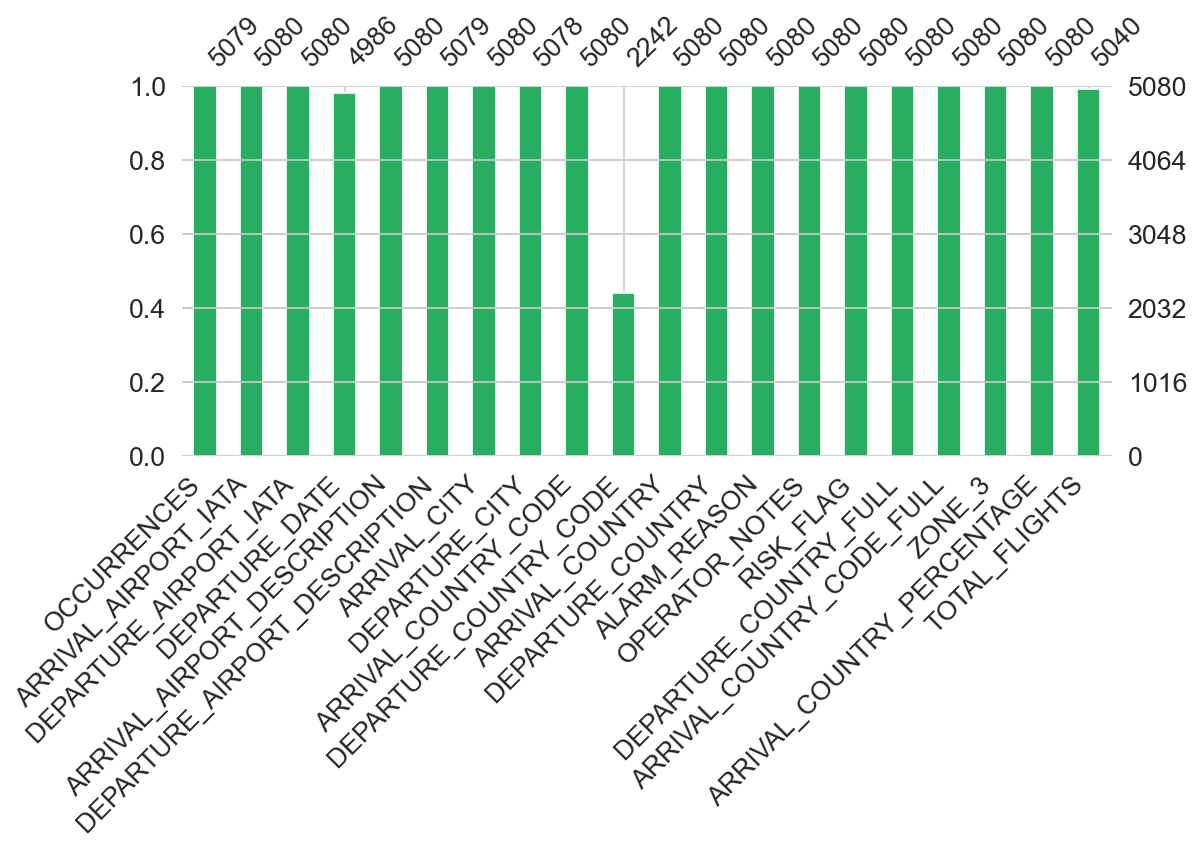

Missingness bar-chart (AFTER cleaning) — Travelers


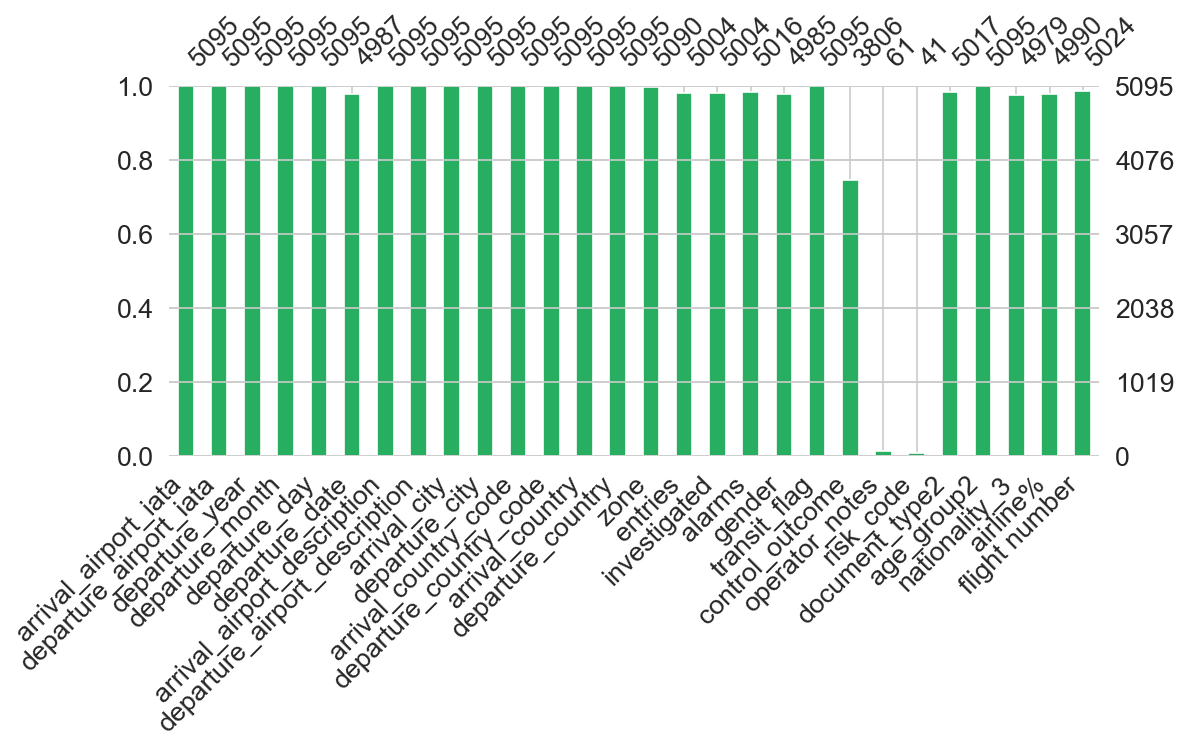

In [445]:
def missing_comparison(df_now, raw_missing, dataset_name, raw_shape):
    """Compare per-column missing-value counts before and after the cleaning pipeline."""
    now = df_now.isnull().sum()
    # Align raw_missing column names to current df naming convention (handles case changes, e.g. alarms → ALARMS)
    col_map = {c.upper(): c for c in df_now.columns}
    raw_missing = raw_missing.copy()
    raw_missing.index = [col_map.get(c.upper(), c) for c in raw_missing.index]
    all_cols = sorted(set(raw_missing.index) | set(now.index))
    rows = [{"Column": c,
             "Missing BEFORE": raw_missing.get(c, "—"),
             "Missing AFTER":  now.get(c, "dropped")} for c in all_cols]
    report = pd.DataFrame(rows).set_index("Column")
    print(f"\n{dataset_name}  (shape: {raw_shape} -> {df_now.shape})")
    display(report)

missing_comparison(df_alarms,    raw_missing_alarms,    "ALARMS",    raw_shape_alarms)
missing_comparison(df_travelers, raw_missing_travelers, "TRAVELERS", raw_shape_travelers)

print("\nMissingness bar-chart (AFTER cleaning) — Alarms")
msno.bar(df_alarms, figsize=(10, 4), color=GREEN); plt.show()

print("Missingness bar-chart (AFTER cleaning) — Travelers")
msno.bar(df_travelers, figsize=(10, 4), color=GREEN); plt.show()

### 2.11 Final schema verification

We print the final shape, column list, and dtype counts for both datasets — the schema contract on which the feature-engineering block will depend. The cleaned DataFrames remain in memory (`df_alarms`, `df_travelers`); no disk persistence is required since the notebook runs end-to-end in a single session.


In [446]:
print(f"ALARMS    — {df_alarms.shape[0]:,} rows x {df_alarms.shape[1]} cols")
print(f"Columns: {list(df_alarms.columns)}")
print(f"Dtypes:\n{df_alarms.dtypes.value_counts().to_string()}\n")

print(f"TRAVELERS — {df_travelers.shape[0]:,} rows x {df_travelers.shape[1]} cols")
print(f"Columns: {list(df_travelers.columns)}")
print(f"Dtypes:\n{df_travelers.dtypes.value_counts().to_string()}")


ALARMS    — 5,080 rows x 20 cols
Columns: ['OCCURRENCES', 'ARRIVAL_AIRPORT_IATA', 'DEPARTURE_AIRPORT_IATA', 'DEPARTURE_DATE', 'ARRIVAL_AIRPORT_DESCRIPTION', 'DEPARTURE_AIRPORT_DESCRIPTION', 'ARRIVAL_CITY', 'DEPARTURE_CITY', 'ARRIVAL_COUNTRY_CODE', 'DEPARTURE_COUNTRY_CODE', 'ARRIVAL_COUNTRY', 'DEPARTURE_COUNTRY', 'ALARM_REASON', 'OPERATOR_NOTES', 'RISK_FLAG', 'DEPARTURE_COUNTRY_FULL', 'ARRIVAL_COUNTRY_CODE_FULL', 'ZONE_3', 'ARRIVAL_COUNTRY_PERCENTAGE', 'TOTAL_FLIGHTS']
Dtypes:
object            19
datetime64[ns]     1

TRAVELERS — 5,095 rows x 28 cols
Columns: ['arrival_airport_iata', 'departure_airport_iata', 'departure_year', 'departure_month', 'departure_day', 'departure_date', 'arrival_airport_description', 'departure_airport_description', 'arrival_city', 'departure_city', 'arrival_country_code', 'departure_country_code', 'arrival_country', 'departure_country', 'zone', 'entries', 'investigated', 'alarms', 'gender', 'transit_flag', 'control_outcome', 'operator_notes', 'risk_code', 'd

## 3. Univariate Analysis

### 3.1 Numerical distributions

For every numeric column we print the descriptive statistics (mean, std, quantiles) and draw a histogram. We use this to detect skewness (common for count data), bounded ranges (e.g. `zone`) and suspicious spikes at the extremes that may indicate residual data-quality issues.

  No numeric columns in Alarms.

  Descriptive statistics — Travelers:


,count,mean,std,min,25%,50%,75%,max
departure_day,5095.00,15.09,8.63,1.00,8.00,15.00,23.00,31.00
zone,5090.00,4.43,2.48,0.00,2.00,4.00,7.00,10.00
entries,5004.00,36.52,47.44,0.00,1.00,3.00,76.00,186.00
investigated,5004.00,35.60,47.31,0.00,1.00,2.00,75.00,186.00
alarms,5016.00,6.47,13.54,0.00,0.00,1.00,10.00,168.00


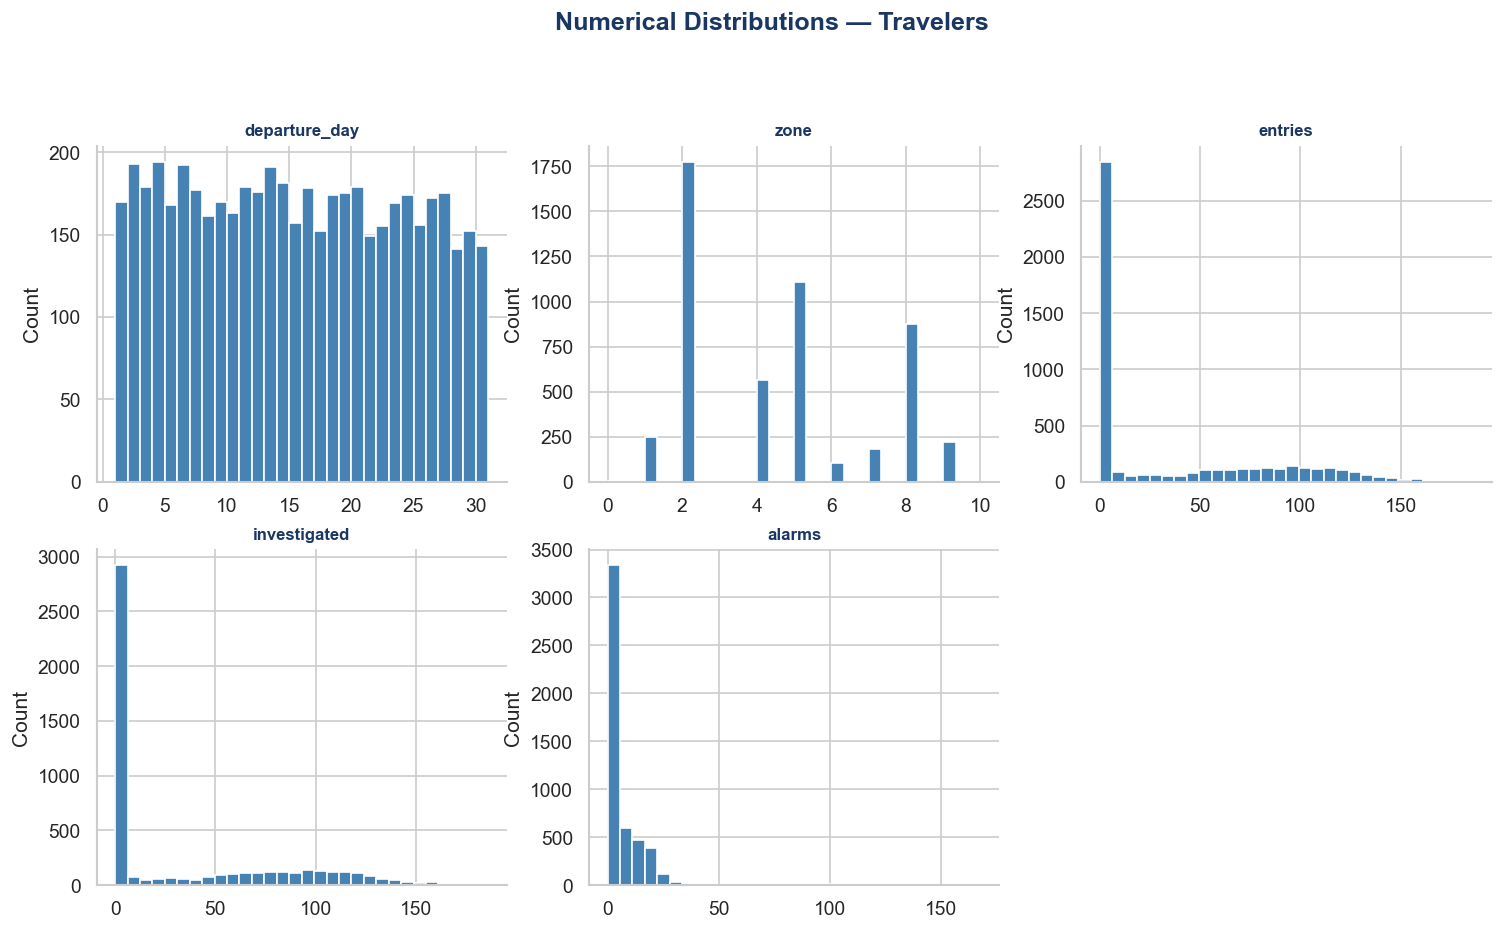

In [447]:
def plot_numeric_distributions(df, dataset_name):
    """Plot histograms and descriptive statistics for every numeric column."""
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if not num_cols:
        print(f"  No numeric columns in {dataset_name}."); return
    print(f"\n  Descriptive statistics — {dataset_name}:")
    display(df[num_cols].describe().T)
    n = len(num_cols); ncols = min(3, n); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    for i, col in enumerate(num_cols):
        ax = axes[i]
        df[col].dropna().hist(bins=30, ax=ax, color=STEEL, edgecolor="white")
        ax.set_title(col, fontsize=10, color=NAVY, fontweight="bold")
        ax.set_ylabel("Count"); sns.despine(ax=ax)
    for j in range(i + 1, len(axes)): axes[j].set_visible(False)
    plt.suptitle(f"Numerical Distributions — {dataset_name}",
                 fontweight="bold", color=NAVY, y=1.02)
    plt.show()

plot_numeric_distributions(df_alarms,    "Alarms")
plot_numeric_distributions(df_travelers, "Travelers")


### 3.2 Categorical frequency analysis

Bar charts of the top-10 values for the business-relevant categoricals. For Alarms these are `ALARM_REASON`, `RISK_FLAG`, `ARRIVAL_COUNTRY_CODE`; for Travelers they are `gender`, `document_type`, `transit_flag`, `age_group`, `control_outcome`. We use `top_n=10` to avoid drawing uninformative long tails.

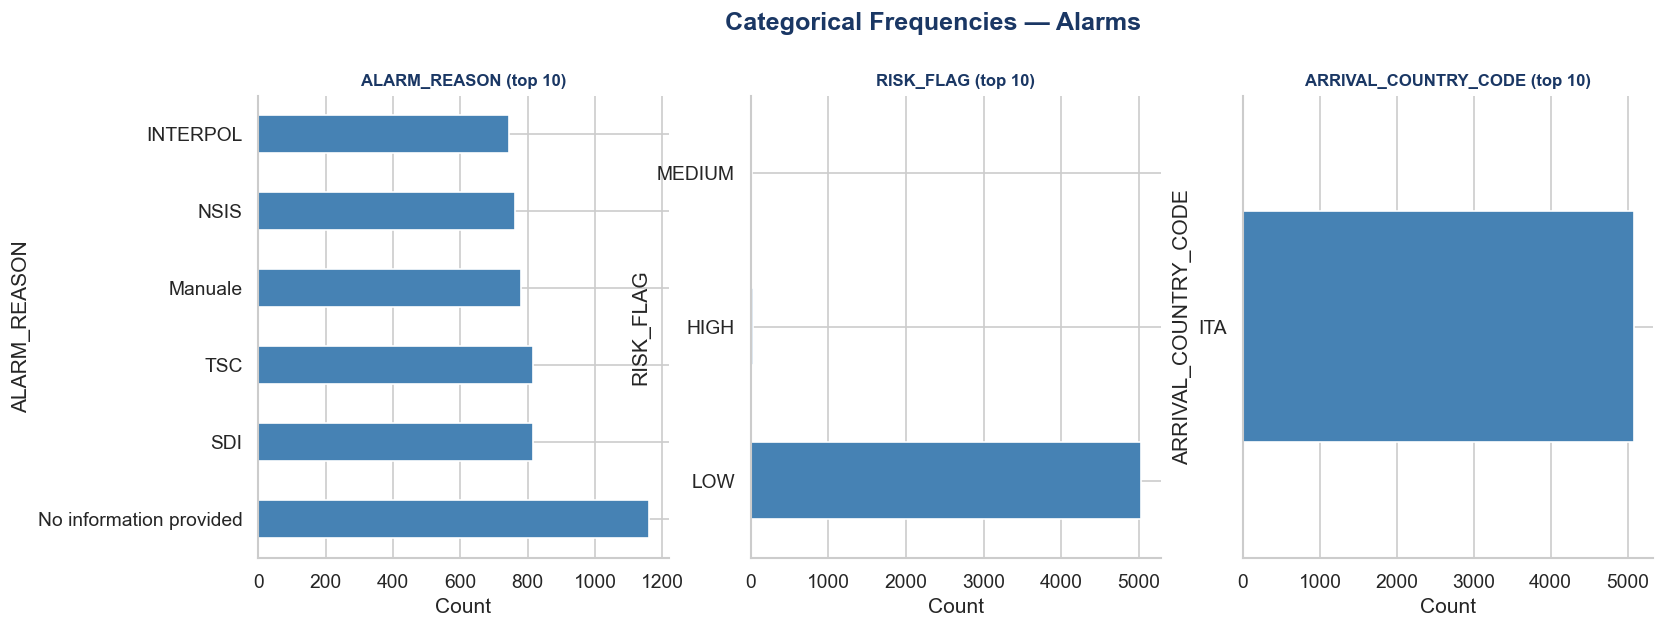

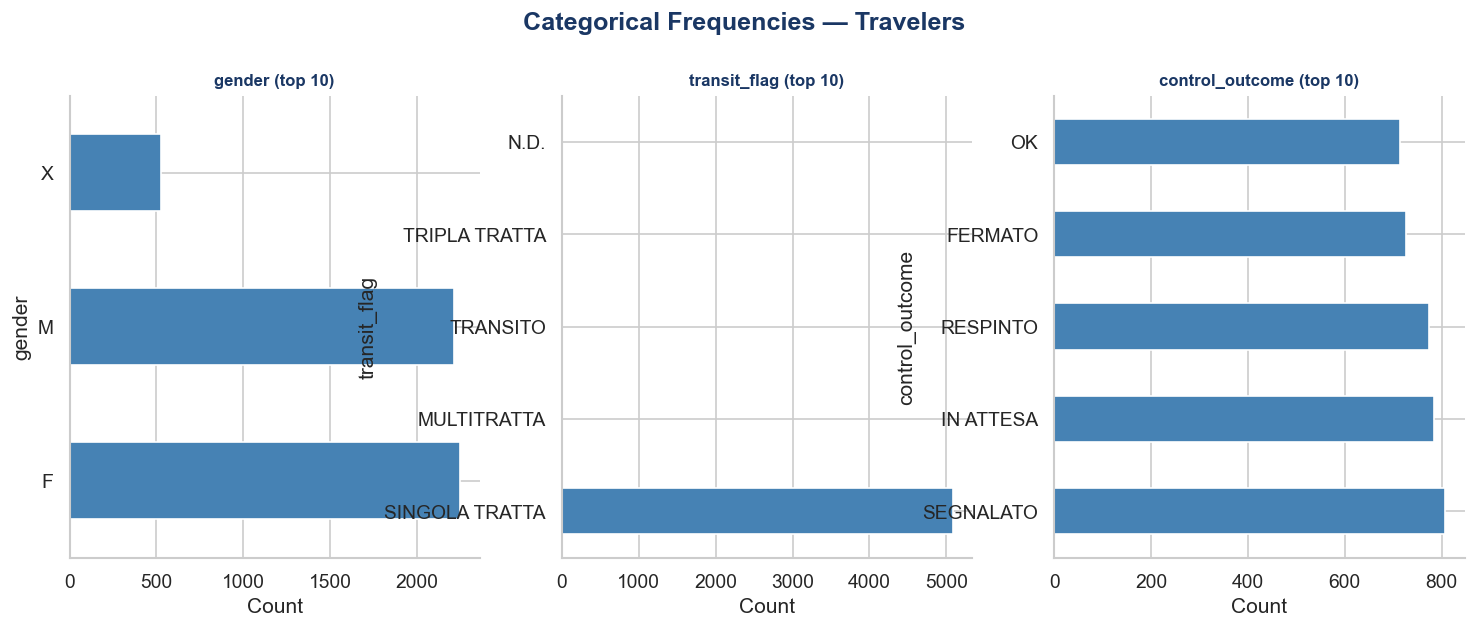

In [448]:
def plot_categorical_freq(df, cols, dataset_name, top_n=10):
    """Plot horizontal bar charts of the top-N values for each requested categorical column."""
    cols = [c for c in cols if c in df.columns]
    if not cols: return
    n = len(cols); fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1: axes = [axes]
    for ax, col in zip(axes, cols):
        df[col].value_counts().head(top_n).plot(kind="barh", ax=ax, color=STEEL, edgecolor="white")
        ax.set_title(f"{col} (top {top_n})", fontsize=10, fontweight="bold", color=NAVY)
        ax.set_xlabel("Count"); sns.despine(ax=ax)
    plt.suptitle(f"Categorical Frequencies — {dataset_name}", fontweight="bold", color=NAVY, y=1.02)
    plt.show()

plot_categorical_freq(df_alarms,    ["ALARM_REASON", "RISK_FLAG", "ARRIVAL_COUNTRY_CODE"], "Alarms")
plot_categorical_freq(df_travelers, ["gender", "document_type", "transit_flag",
                                     "age_group", "control_outcome"], "Travelers")

### 3.3 Temporal distribution

We aggregate records at the *month* granularity and plot them as bar charts. The shape of these two time-series tells us (a) whether the coverage period of the two datasets aligns and (b) whether there are any obvious reporting gaps that could bias time-series feature engineering later on.

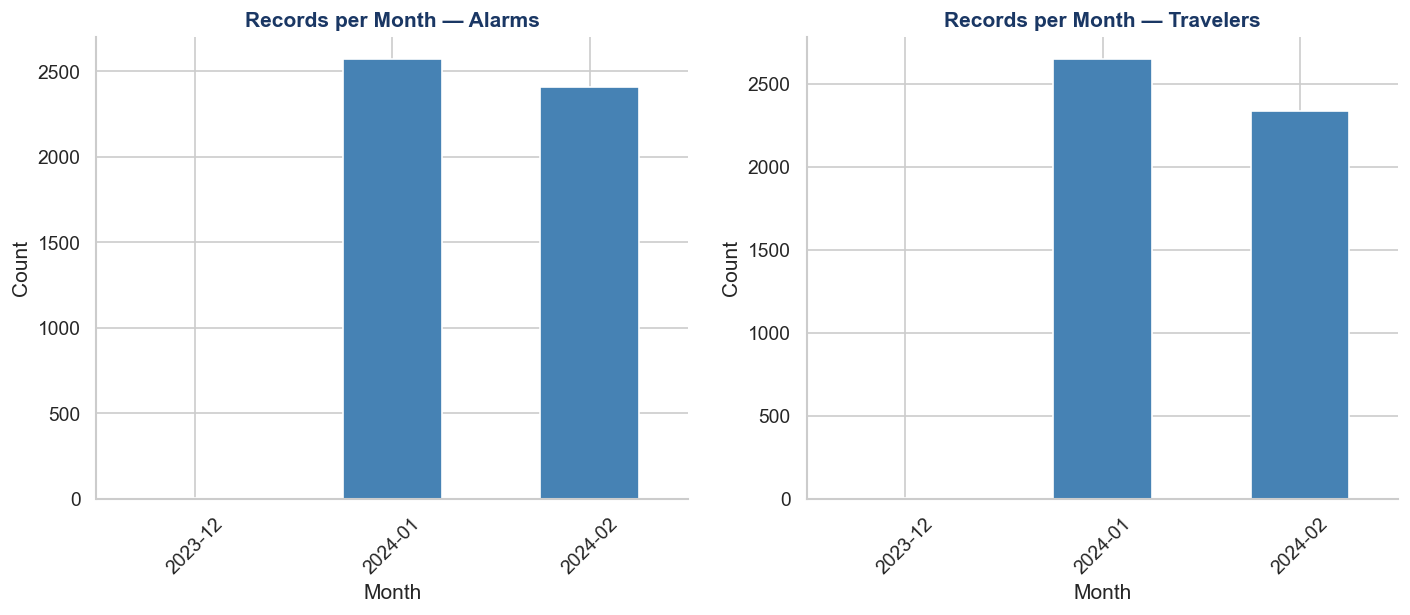

In [449]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df_tmp, name) in zip(axes, [(df_alarms, "Alarms"), (df_travelers, "Travelers")]):
    date_col = "DEPARTURE_DATE" if "DEPARTURE_DATE" in df_tmp.columns else "departure_date"
    if date_col not in df_tmp.columns: continue
    monthly = df_tmp[date_col].dropna().dt.to_period("M").value_counts().sort_index()
    monthly.plot(kind="bar", ax=ax, color=STEEL, edgecolor="white")
    ax.set_title(f"Records per Month — {name}", fontweight="bold", color=NAVY)
    ax.set_xlabel("Month"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45); sns.despine(ax=ax)


## 4. Bivariate Analysis

### 4.1 Entries vs Alarms

The Pearson correlation between passenger `entries` and `alarms` quantifies whether alarm volume simply tracks traffic (a high correlation would mean "bigger airports trigger more alarms just because they have more flow") or whether some routes/days show *excess* alarms given traffic. The latter is exactly the signal we will want to isolate during anomaly detection.

  Pearson r(entries, alarms) = 0.580


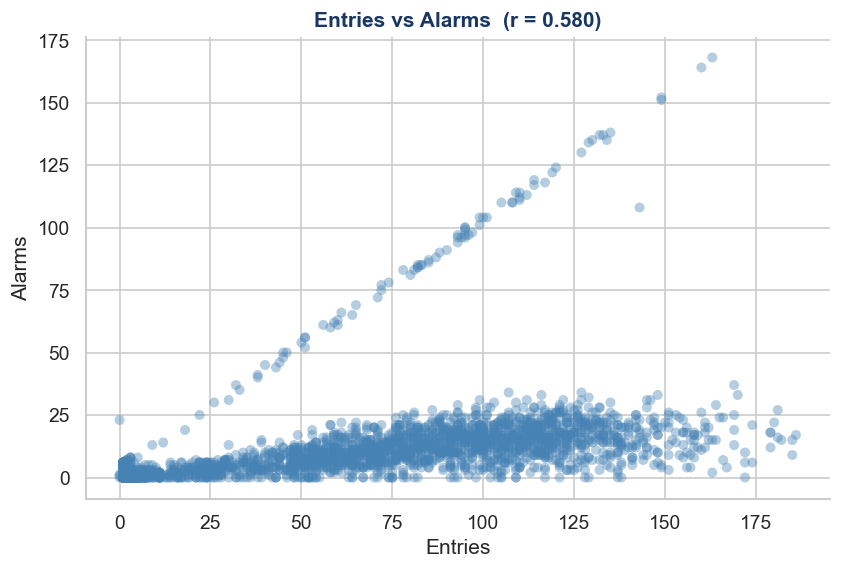

In [450]:
if {"entries", "alarms"}.issubset(df_travelers.columns):
    corr = df_travelers[["entries", "alarms"]].corr().iloc[0, 1]
    print(f"  Pearson r(entries, alarms) = {corr:.3f}")
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_travelers, x="entries", y="alarms", alpha=0.4, color=STEEL, edgecolor="none")
    plt.title(f"Entries vs Alarms  (r = {corr:.3f})", fontweight="bold", color=NAVY)
    plt.xlabel("Entries"); plt.ylabel("Alarms"); sns.despine()
else:
    print("'entries' or 'alarms' column not found — skipping.")

### 4.2 Alarm Reason × Zone heatmap

A crosstab of `ALARM_REASON` against `ZONE_3` tells us which types of alarms concentrate in which geographic risk zones. Reading the heatmap row-wise highlights alarm categories that cluster in a single zone (narrow operational footprint); column-wise, it shows zones that receive a disproportionate share of a particular alarm type — both patterns are candidate priors for the anomaly detector.

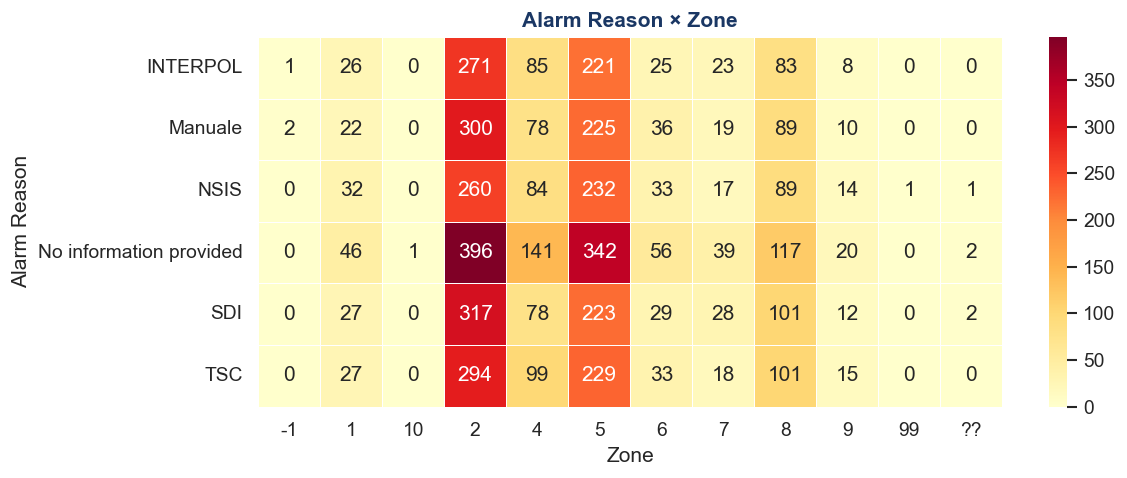

In [451]:
zone_col   = "ZONE_3" if "ZONE_3" in df_alarms.columns else "ZONE"
reason_col = "ALARM_REASON" if "ALARM_REASON" in df_alarms.columns else None

if reason_col and zone_col in df_alarms.columns:
    ct = pd.crosstab(df_alarms[reason_col], df_alarms[zone_col])
    plt.figure(figsize=(10, max(4, len(ct) * 0.5)))
    sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
    plt.title("Alarm Reason × Zone", fontweight="bold", color=NAVY)
    plt.ylabel("Alarm Reason"); plt.xlabel("Zone")
else:
    print("Required columns not available — skipping.")

### 4.3 Top routes by volume

We rank all (departure IATA → arrival IATA) pairs by alarm count and visualise the top 15. These are the routes where the data density is highest, so baseline statistics computed over them will be the most reliable; smaller routes will need regularisation or pooling.

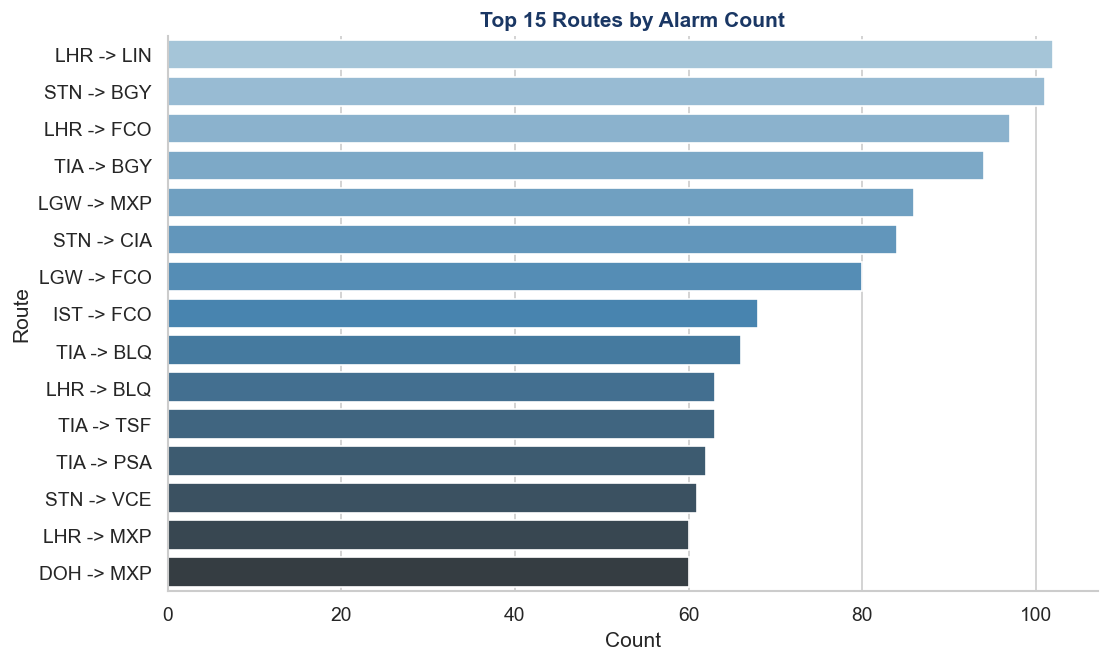

,route,count
183,LHR -> LIN,102
294,STN -> BGY,101
182,LHR -> FCO,97
324,TIA -> BGY,94
175,LGW -> MXP,86
298,STN -> CIA,84
172,LGW -> FCO,80
142,IST -> FCO,68
325,TIA -> BLQ,66
181,LHR -> BLQ,63


In [452]:
dep_col = "DEPARTURE_AIRPORT_IATA" if "DEPARTURE_AIRPORT_IATA" in df_alarms.columns else None
arr_col = "ARRIVAL_AIRPORT_IATA"   if "ARRIVAL_AIRPORT_IATA"   in df_alarms.columns else None

if dep_col and arr_col:
    routes = (df_alarms.groupby([dep_col, arr_col]).size()
              .reset_index(name="count")
              .sort_values("count", ascending=False)
              .head(15))
    routes["route"] = routes[dep_col] + " -> " + routes[arr_col]
    plt.figure(figsize=(10, 6))
    # Pass `hue` to use a palette safely across seaborn versions (>=0.14).
    sns.barplot(data=routes, y="route", x="count",
                hue="route", palette="Blues_d", legend=False)
    plt.title("Top 15 Routes by Alarm Count", fontweight="bold", color=NAVY)
    plt.xlabel("Count"); plt.ylabel("Route"); sns.despine()
    plt.show()
    display(routes[["route", "count"]])
else:
    print("Airport IATA columns not available — skipping.")


## 5. Multivariate Analysis

### 5.1 Numeric correlation matrix

We plot the lower-triangular Pearson correlation matrix for each dataset. This flags *multi-collinearity* (features that move together and will dominate distance-based methods like LOF if left unscaled) and tells us which raw numerics carry redundant information before we start crafting engineered features.

  Not enough numeric columns in Alarms.


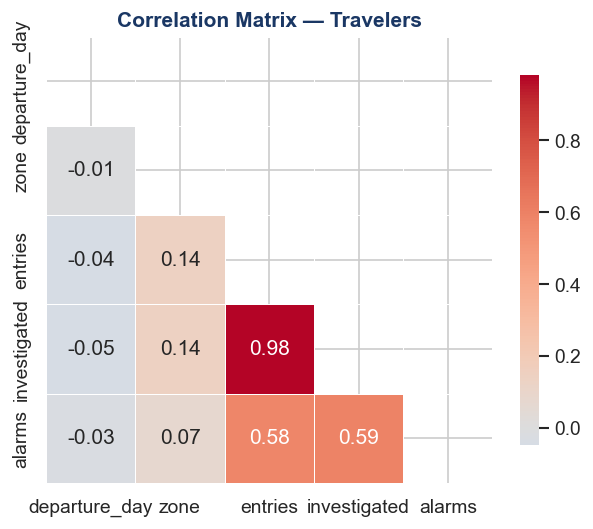

In [453]:
def plot_corr_matrix(df, dataset_name):
    """Plot the lower-triangular Pearson correlation matrix of the numeric columns."""
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if len(num_cols) < 2:
        print(f"  Not enough numeric columns in {dataset_name}."); return
    corr = df[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(max(6, len(num_cols)), max(5, len(num_cols) * 0.8)))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
                cmap="coolwarm", center=0, linewidths=0.5, square=True,
                cbar_kws={"shrink": 0.8})
    plt.title(f"Correlation Matrix — {dataset_name}", fontweight="bold", color=NAVY)
    plt.show()

plot_corr_matrix(df_alarms,    "Alarms")
plot_corr_matrix(df_travelers, "Travelers")


### 5.2 Pair plot — Travelers

Pair plot over `entries`, `investigated`, `alarms`, `zone` (sampled to 2 000 points for responsiveness). The off-diagonal panels let us see *joint* structure (e.g. whether alarms grow linearly or sub-linearly with entries), while the KDE diagonals confirm the marginal distributions already seen in section 3.1.

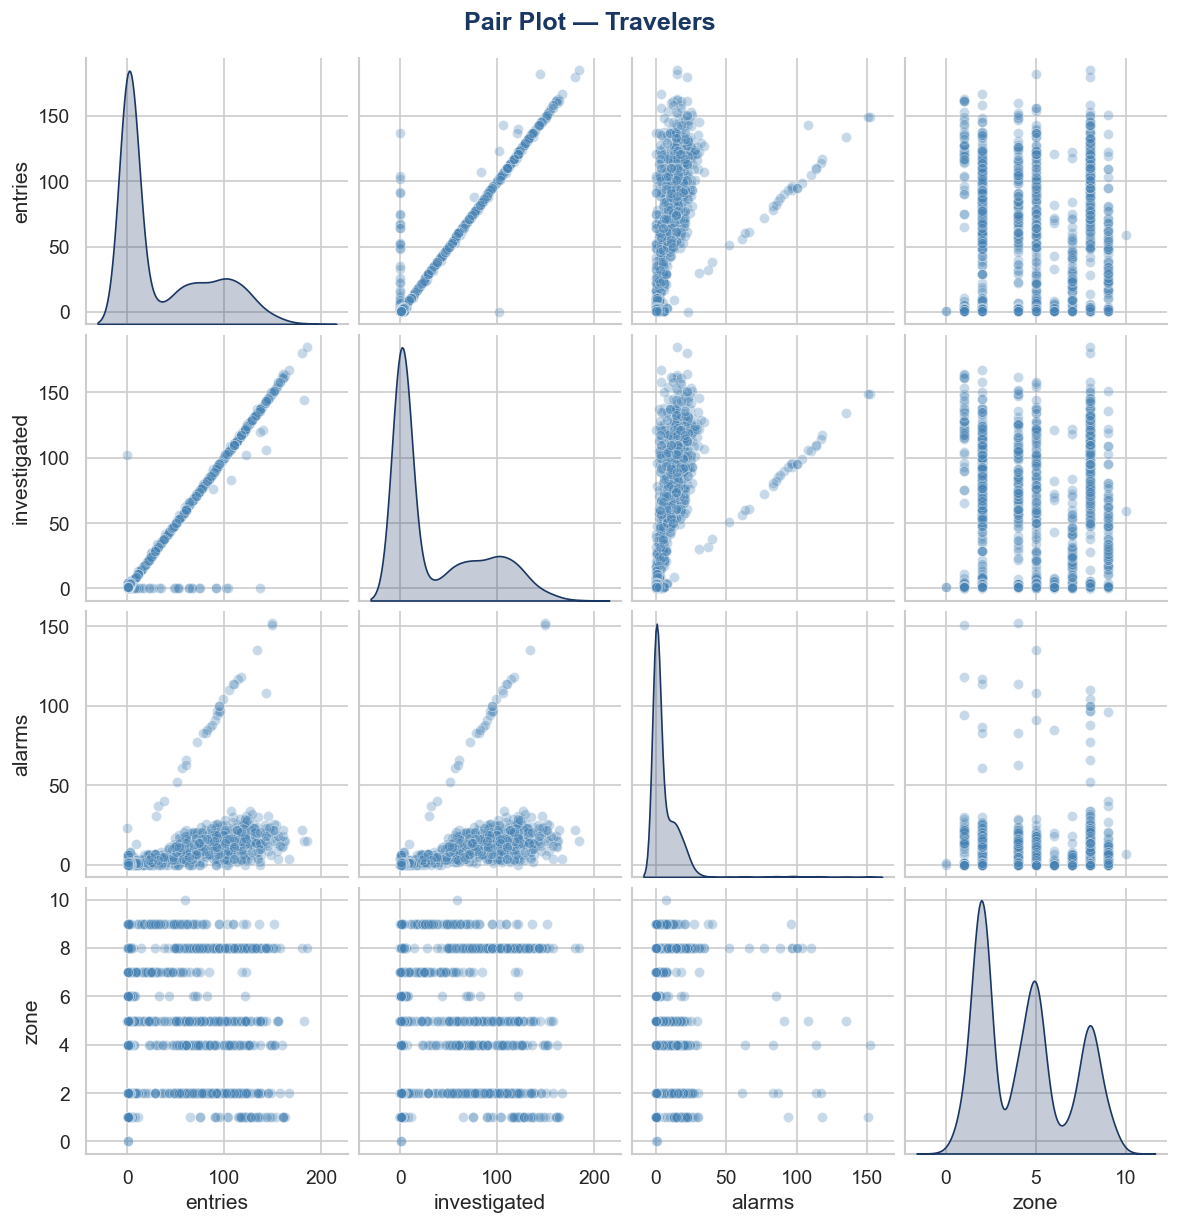

In [454]:
pair_cols = [c for c in ["entries", "investigated", "alarms", "zone"]
             if c in df_travelers.columns]
if len(pair_cols) >= 2:
    sample = df_travelers[pair_cols].dropna()
    if len(sample) > 2000: sample = sample.sample(2000, random_state=42)
    g = sns.pairplot(sample, diag_kind="kde",
                     plot_kws={"alpha": 0.3, "color": STEEL},
                     diag_kws={"color": NAVY})
    g.figure.suptitle("Pair Plot — Travelers", y=1.02, fontweight="bold", color=NAVY)
else:
    print("Not enough numeric columns for pair plot.")

## 6. Outlier Analysis

### 6.1 IQR-based outlier detection

We apply the standard 1.5·IQR rule to every numeric column and tabulate: quartiles, IQR, lower/upper bounds, number of outliers and their share of the column. The result is *descriptive*, not prescriptive — for right-skewed count distributions like `entries` and `total_flights` a large tail is expected, and we won't remove those observations; instead, the tail itself becomes one of the signals the anomaly detector consumes.

In [455]:
def iqr_outlier_report(df, dataset_name):
    num_cols = df.select_dtypes(include="number").columns.tolist()
    rows = []
    for col in num_cols:
        s = df[col].dropna()
        if len(s) == 0: continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1; lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lower) | (s > upper)).sum()
        rows.append({"Column": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                     "Lower": lower, "Upper": upper, "Outliers": n_out,
                     "Outlier %": round(n_out / len(s) * 100, 2)})
    if not rows:
        print(f"{dataset_name} — IQR Outlier Report: no numeric columns found.")
        return pd.DataFrame()
    report = pd.DataFrame(rows).set_index("Column")
    print(f"{dataset_name} — IQR Outlier Report:")
    display(report); return report

iqr_alarms    = iqr_outlier_report(df_alarms,    "Alarms")
iqr_travelers = iqr_outlier_report(df_travelers, "Travelers")

Alarms — IQR Outlier Report: no numeric columns found.
Travelers — IQR Outlier Report:


,Q1,Q3,IQR,Lower,Upper,Outliers,Outlier %
Column,,,,,,,
departure_day,8.00,23.00,15.00,-14.50,45.50,0,0.00
zone,2.00,7.00,5.00,-5.50,14.50,0,0.00
entries,1.00,76.00,75.00,-111.50,188.50,0,0.00
investigated,1.00,75.00,74.00,-110.00,186.00,0,0.00
alarms,0.00,10.00,10.00,-15.00,25.00,142,2.83


### 6.2 Box plots — key metrics

Visual companion to the IQR table. For each key quantitative column we draw the box plot and highlight fliers in coral. The box summarises the bulk of the distribution; the whiskers show the natural spread; the coral dots are the rows the anomaly detector will later have to classify as *expected-extreme* vs *genuinely-anomalous*.

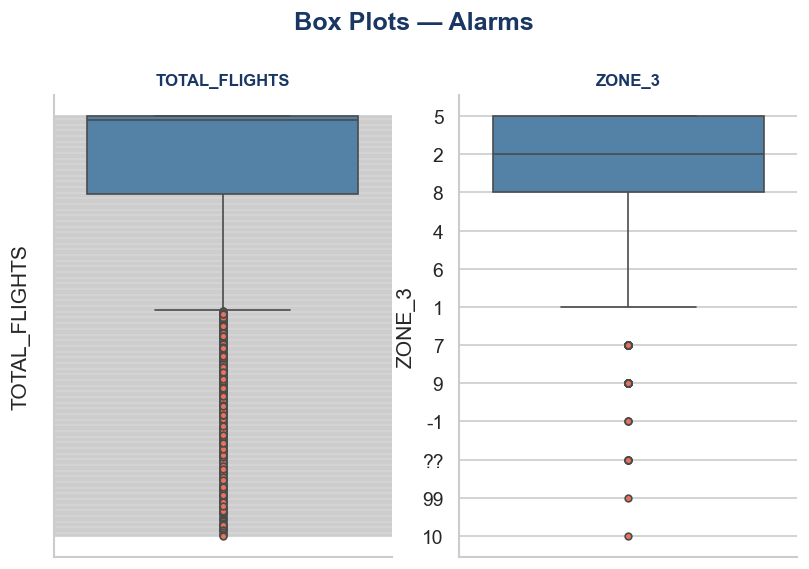

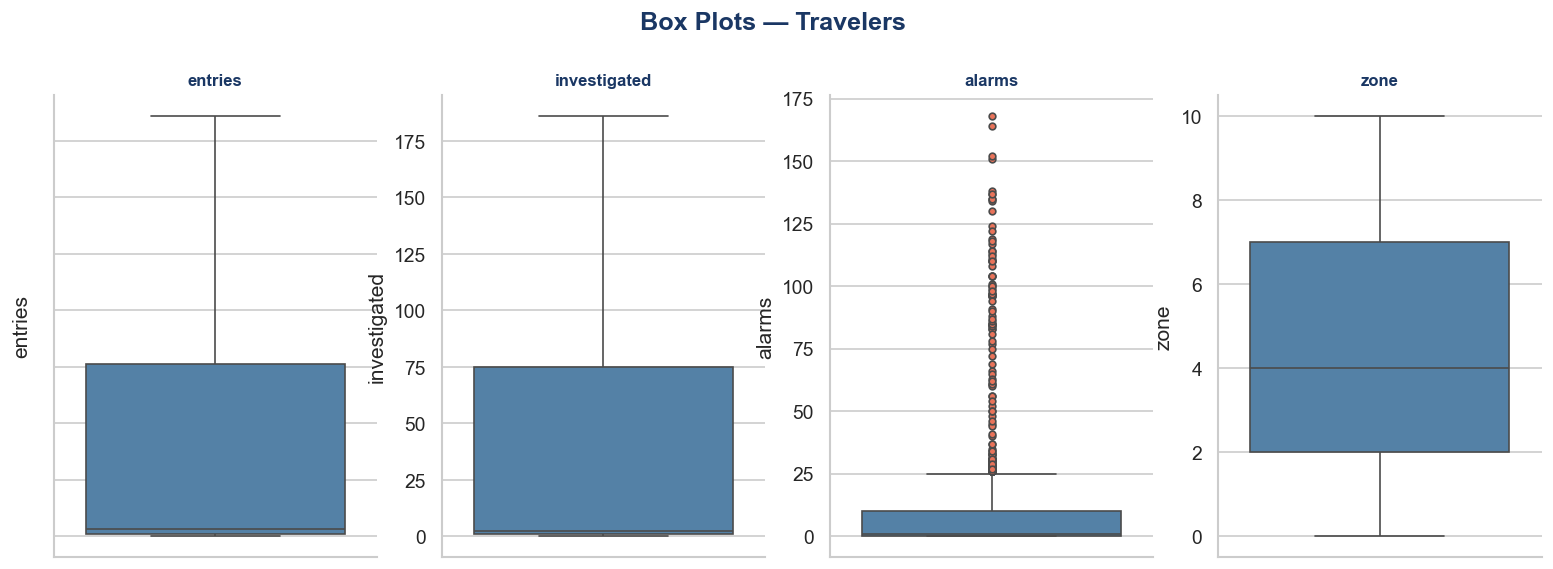

In [456]:
def plot_boxplots(df, cols, dataset_name):
    """Plot a box plot for each requested column, with fliers highlighted in coral."""
    cols = [c for c in cols if c in df.columns]
    if not cols: return
    n = len(cols); fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes = [axes]
    for i, (ax, col) in enumerate(zip(axes, cols)):
        sns.boxplot(y=df[col].dropna(), ax=ax, color=STEEL,
                    flierprops={"marker": "o", "markerfacecolor": CORAL, "markersize": 4})
        ax.set_title(col, fontsize=10, fontweight="bold", color=NAVY); sns.despine(ax=ax)
        if i == 0:
            ax.yaxis.set_ticklabels([])
    plt.suptitle(f"Box Plots — {dataset_name}", fontweight="bold", color=NAVY, y=1.02)
    plt.show()

plot_boxplots(df_alarms,    ["TOTAL_FLIGHTS", "ZONE_3"], "Alarms")
plot_boxplots(df_travelers, ["entries", "investigated", "alarms", "zone"], "Travelers")

## 7. Cross-Dataset Coverage

### 7.1 Temporal overlap

To be able to join the two datasets on date, we compute the min/max of `departure_date` in each and report the intersection. If the overlap is empty we must rescope; if it is short, the Feature-Engineering block will need to be careful about time-series windows.

In [457]:
date_al = "DEPARTURE_DATE" if "DEPARTURE_DATE" in df_alarms.columns else "departure_date"
date_tr = "departure_date"

if date_al in df_alarms.columns and date_tr in df_travelers.columns:
    al_min, al_max = df_alarms[date_al].min(),   df_alarms[date_al].max()
    tr_min, tr_max = df_travelers[date_tr].min(), df_travelers[date_tr].max()
    print(f"  Alarms    : {al_min} → {al_max}")
    print(f"  Travelers : {tr_min} → {tr_max}")
    overlap_start = max(al_min, tr_min); overlap_end = min(al_max, tr_max)
    if overlap_start <= overlap_end:
        print(f"  Overlap : {overlap_start} → {overlap_end}")
    else:
        print("   No temporal overlap between datasets!")

  Alarms    : 2023-12-31 00:00:00 → 2024-02-29 22:20:00
  Travelers : 2023-12-31 19:35:00 → 2024-02-29 21:55:00
  Overlap : 2023-12-31 19:35:00 → 2024-02-29 21:55:00


### 7.2 Airport & route coverage (Jaccard)

Even when the dates overlap, the two datasets may cover different airports. We compute the Jaccard index between the IATA sets so that we know, before joining, how much of the Travelers signal can actually be enriched with alarm details.

In [458]:
def coverage_report(col_alarms, col_travelers, label):
    al_col = col_alarms.upper() if col_alarms.upper() in df_alarms.columns else col_alarms
    tr_col = col_travelers
    if al_col not in df_alarms.columns or tr_col not in df_travelers.columns:
        print(f"  ⚠ '{label}' columns not found — skipping."); return
    set_al = set(df_alarms[al_col].dropna().astype(str).str.upper().unique())
    set_tr = set(df_travelers[tr_col].dropna().astype(str).str.upper().unique())
    inter = set_al & set_tr; union = set_al | set_tr
    jaccard = len(inter) / len(union) if union else 0
    print(f"  {label}:")
    print(f"    Alarms only   : {len(set_al - set_tr)}")
    print(f"    Travelers only: {len(set_tr - set_al)}")
    print(f"    Shared        : {len(inter)}")
    print(f"    Jaccard index : {jaccard:.2%}")

coverage_report("DEPARTURE_AIRPORT_IATA", "departure_airport_iata", "Departure Airport (IATA)")
coverage_report("ARRIVAL_AIRPORT_IATA",   "arrival_airport_iata",   "Arrival Airport (IATA)")

  Departure Airport (IATA):
    Alarms only   : 21
    Travelers only: 86
    Shared        : 91
    Jaccard index : 45.96%
  Arrival Airport (IATA):
    Alarms only   : 3
    Travelers only: 1
    Shared        : 28
    Jaccard index : 87.50%


### 7.3 Final EDA summary

Six take-aways that drive the Feature-Engineering choices in section 8:

1. **Quality** — dates normalised; redundant columns merged and dropped; missing-token variants unified.
2. **Missingness** — residual NaNs concentrate on truly optional fields (operator notes, risk codes, airline details).
3. **Cardinality** — `flight_number`, `airline` are high-cardinality and will need grouping/target encoding downstream.
4. **Distributions** — `entries` and `alarms` are right-skewed; log-scale or ratio-based features will help distance-based detectors.
5. **Outliers** — IQR flags extreme values in `entries` and `total_flights`; we keep them (they *are* the signal).
6. **Cross-dataset** — temporal overlap confirmed; partial airport overlap implies a `left` join on Travelers as the base table.

In [459]:
print(f"""
  ALARMS dataset  : {df_alarms.shape[0]:,} rows × {df_alarms.shape[1]} columns
  TRAVELERS dataset: {df_travelers.shape[0]:,} rows × {df_travelers.shape[1]} columns
""")


  ALARMS dataset  : 5,080 rows × 20 columns
  TRAVELERS dataset: 5,095 rows × 28 columns



## 8. Feature engineering

The next four subsections transform the two cleaned tables into a single model-ready feature panel. The data-cleaning block has already normalised dtypes and free-text categoricals; here we focus on semantic alignment (shared temporal grain) and on the join that produces a master observation unit.

### 8.1 In-memory handover

The cleaned datasets produced in section 2 are already in memory as `df_alarms` and `df_travelers`. We alias them to shorter names for the feature-engineering block.


In [460]:
# In-memory handover from section 2; no disk persistence needed.
df_trav = df_travelers.copy()
df_alar = df_alarms.copy()

print(f"Travelers: {df_trav.shape}")
print(f"Alarms:    {df_alar.shape}")

Travelers: (5095, 28)
Alarms:    (5080, 20)


### 8.2 Post-handover reconciliation

Any row whose `departure_date` failed to parse (and is now `NaT`) cannot be aligned on time and would be silently dropped by any date-keyed join — so we drop it explicitly here, with a printed count. Because the cleaning block already produced well-typed outputs, no additional imputation is performed at this stage.


In [461]:
before = len(df_trav)
df_trav = df_trav.dropna(subset=["departure_date"])
print(f"Travelers: dropped {before - len(df_trav)} rows with NaT departure_date")

before = len(df_alar)
df_alar = df_alar.dropna(subset=["DEPARTURE_DATE"])
print(f"Alarms:    dropped {before - len(df_alar)} rows with NaT DEPARTURE_DATE")


Travelers: dropped 108 rows with NaT departure_date
Alarms:    dropped 94 rows with NaT DEPARTURE_DATE


### 8.3 Temporal alignment & rich alarm-reason aggregation

We bring both tables to the same temporal grain (daily, normalised via `dt.normalize()`) and produce a pivot of the Alarms dataset:

- one-hot encode `ALARM_REASON` and `RISK_FLAG`;
- sum each dummy per (day, departure-IATA) so that every row becomes a vector "how many alarms of each type happened at this airport on this day";
- add a `total_alarms_day` scalar.

This is the *rich aggregation* that turns the raw event log into a daily, airport-keyed feature panel.

In [462]:
df_trav["merge_date"] = pd.to_datetime(df_trav["departure_date"]).dt.normalize()
df_alar["merge_date"] = pd.to_datetime(df_alar["DEPARTURE_DATE"]).dt.normalize()

# One-hot encode alarm categoricals and aggregate by (day, airport)
alarms_dummies = pd.get_dummies(df_alar[["ALARM_REASON", "RISK_FLAG"]],
                                prefix=["ALARM_REASON", "RISK_FLAG"])
df_alar_rich   = pd.concat([df_alar[["merge_date", "DEPARTURE_AIRPORT_IATA"]],
                            alarms_dummies], axis=1)

alarms_grouped = (df_alar_rich
                  .groupby(["merge_date", "DEPARTURE_AIRPORT_IATA"]).sum()
                  .reset_index())

total_counts   = (df_alar.groupby(["merge_date", "DEPARTURE_AIRPORT_IATA"])
                  .size().reset_index(name="total_alarms_day"))

alarms_grouped = alarms_grouped.merge(total_counts,
                                      on=["merge_date", "DEPARTURE_AIRPORT_IATA"])

print(f"  Aggregated alarms panel: {alarms_grouped.shape}")
display(alarms_grouped.head(3))

  Aggregated alarms panel: (2013, 12)


,merge_date,DEPARTURE_AIRPORT_IATA,ALARM_REASON_INTERPOL,ALARM_REASON_Manuale,ALARM_REASON_NSIS,ALARM_REASON_No information provided,ALARM_REASON_SDI,ALARM_REASON_TSC,RISK_FLAG_HIGH,RISK_FLAG_LOW,RISK_FLAG_MEDIUM,total_alarms_day
0,2023-12-31,EWR,0,0,0,1,0,0,0,1,0,1
1,2023-12-31,EZE,0,0,0,0,0,1,0,1,0,1
2,2023-12-31,GRU,1,0,0,0,0,0,0,1,0,1


### 8.4 Master dataset (the merge)

We left-join the Travelers table (our base observation unit) against the aggregated Alarms panel on `(merge_date, departure_airport_iata)`. Travelers rows with no matching alarms get `0`s in every one-hot column — they genuinely had zero alarms that day at that airport, so `0` is the correct semantic fill.

In [463]:
df_master = df_trav.merge(alarms_grouped,
                          left_on =["merge_date", "departure_airport_iata"],
                          right_on=["merge_date", "DEPARTURE_AIRPORT_IATA"],
                          how="left")

# Left-join semantics: a Travelers row with no matching Alarms row genuinely
# had zero alarms that day at that airport, so 0 is the correct fill for the
# alarm one-hot columns and for total_alarms_day.
alarm_cols = [c for c in df_master.columns if c.startswith(("ALARM_REASON_", "RISK_FLAG_"))]
df_master[alarm_cols + ["total_alarms_day"]] = (
    df_master[alarm_cols + ["total_alarms_day"]].fillna(0))

df_master = df_master.drop(columns=["DEPARTURE_AIRPORT_IATA", "merge_date"],
                           errors="ignore")

print(f"MASTER DATASET: {df_master.shape[0]:,} rows, {df_master.shape[1]} columns")
display(df_master.head(3))

MASTER DATASET: 4,987 rows, 38 columns


,arrival_airport_iata,departure_airport_iata,departure_year,departure_month,departure_day,departure_date,arrival_airport_description,departure_airport_description,arrival_city,departure_city,arrival_country_code,departure_country_code,arrival_country,departure_country,zone,entries,investigated,alarms,gender,transit_flag,control_outcome,operator_notes,risk_code,document_type2,age_group2,nationality_3,airline%,flight number,ALARM_REASON_INTERPOL,ALARM_REASON_Manuale,ALARM_REASON_NSIS,ALARM_REASON_No information provided,ALARM_REASON_SDI,ALARM_REASON_TSC,RISK_FLAG_HIGH,RISK_FLAG_LOW,RISK_FLAG_MEDIUM,total_alarms_day
0,NAP,DUR,2024,02,13,2024-02-13 07:30:00,NAPOLI CAPODICHINO,KING SHAKA INTERNATIONAL,NAPOLI,DURBAN,ITA,ZAF,ITALIA,SUDAFRICA,6,1,1,0,F,SINGOLA TRATTA,RESPINTO,NaN,NaN,PASSAPORTO,N.D.,ALB,FLY DUBAI,FZ1681,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,FCO,JFK,2024,01,22,2024-01-22 16:35:00,FIUMICINO,JOHN F KENNEDY INTERNATIONAL,ROMA,NEW YORK,ITA,USA,ITALIA,STATI UNITI,5,1,0,1,F,SINGOLA TRATTA,NaN,NaN,NaN,CARTA D'IDENTITÀ,18-30,ALB,ITA AIRWAYS,AZ0609,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00
2,TSF,TIA,2024,02,4,2024-02-04 20:10:00,TREVISO-SANT'ANGELO,RINAS MOTHER TERESA,TREVISO,TIRANA,ITA,ALB,ITALIA,ALBANIA,4,58,58,13,F,SINGOLA TRATTA,SEGNALATO,NaN,NaN,N.D.,31-45,ALB,RYANAIR DAC,FR8400,0.00,1.00,2.00,5.00,2.00,2.00,0.00,12.00,0.00,12.00


## 9. Engineered features

We now construct the signal features that the anomaly detector will consume. Each feature answers a business-level question:

- `is_weekend` — does calendar day-of-week carry risk?
- `month` — monthly seasonality.
- `alarm_rate` — how alarm-dense is today's traffic?
- `investigation_rate` — fraction of entries that were investigated.
- `airport_historical_avg_rate` — what does "normal" look like at this airport?
- `rate_deviation` — signed deviation from the baseline alarm rate.
- `alarm_rate_yesterday`, `rolling_7d_avg_rate` — short-term momentum.
- `airport_historical_avg_entries`, `traffic_multiplier` — is today's volume itself abnormal?
- `zone_risk_weight` — geographic risk weight derived from the `zone` column.

### 9.1 Rates and per-airport baselines

The per-airport historical baseline `airport_historical_avg_rate` is computed over the full observation window. In a production scoring setting this should be fitted on a strictly earlier training window to avoid look-ahead bias; in the present unsupervised offline exercise the entire window is the reference set, and the sample mean is the natural estimator. We acknowledge this limitation in section 15.2.


In [464]:
# Temporal context features
df_master["day_of_week"] = pd.to_datetime(df_master["departure_date"]).dt.dayofweek
df_master["is_weekend"]  = np.where(df_master["day_of_week"] >= 5, 1, 0)
df_master["month"]       = pd.to_datetime(df_master["departure_date"]).dt.month

# Core rate feature: fraction of entries that triggered an alarm
entries = df_master["entries"].fillna(0).astype(float)
df_master["alarm_rate"] = np.where(entries > 0,
                                   df_master["total_alarms_day"].fillna(0).astype(float) / entries,
                                   0)

# Scrutiny-intensity feature: fraction of entries investigated
df_master["investigation_rate"] = np.where(entries > 0,
                                           df_master["investigated"].fillna(0).astype(float) / entries,
                                           0)

# Per-airport historical alarm-rate baseline (whole-period mean)
airport_baseline = (df_master.groupby("departure_airport_iata")["alarm_rate"]
                    .mean().reset_index()
                    .rename(columns={"alarm_rate": "airport_historical_avg_rate"}))
df_master = df_master.merge(airport_baseline, on="departure_airport_iata", how="left")

# Deviation from baseline (signed)
df_master["rate_deviation"] = df_master["alarm_rate"] - df_master["airport_historical_avg_rate"]

print("Features built: alarm_rate, investigation_rate, "
      "airport_historical_avg_rate, rate_deviation")

Features built: alarm_rate, investigation_rate, airport_historical_avg_rate, rate_deviation


### 9.2 Time-series lag and rolling features

Two strictly-historical features are computed per airport:

- `alarm_rate_yesterday` — the previous day's value, obtained with `shift(1)`.
- `rolling_7d_avg_rate` — the mean of the **previous** seven days. Since the current row is itself the score target, the rolling window must exclude it; a plain `rolling(7).mean()` would include the current day and produce a trivial self-match at inference time, a textbook look-ahead bias. The correct pattern is therefore `.shift(1).rolling(7)`, which produces a strictly-past window.

The first observation per airport has no past to look back at; we fall back to the per-airport historical baseline, which is a neutral prior.


In [465]:
# Sort chronologically within each airport group
df_master = df_master.sort_values(by=["departure_airport_iata", "departure_date"])

# Lag(1) — yesterday's alarm rate
df_master["alarm_rate_yesterday"] = (
    df_master.groupby("departure_airport_iata")["alarm_rate"].shift(1)
)

# Strictly-past 7-day rolling mean (shift(1) then rolling prevents look-ahead)
df_master["rolling_7d_avg_rate"] = (
    df_master.groupby("departure_airport_iata")["alarm_rate"]
             .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

# Fallback for the very first observation per airport: use the baseline
df_master["alarm_rate_yesterday"] = df_master["alarm_rate_yesterday"].fillna(
    df_master["airport_historical_avg_rate"])
df_master["rolling_7d_avg_rate"]  = df_master["rolling_7d_avg_rate"].fillna(
    df_master["airport_historical_avg_rate"])

print("Time-series features built (leak-free): alarm_rate_yesterday, rolling_7d_avg_rate")


Time-series features built (leak-free): alarm_rate_yesterday, rolling_7d_avg_rate


### 9.3 Engineered-feature correlation check

Quick sanity check: we want the engineered features to capture *distinct* signals. Any pair with |r| > 0.9 is a candidate for removal in the feature-selection step section 10.

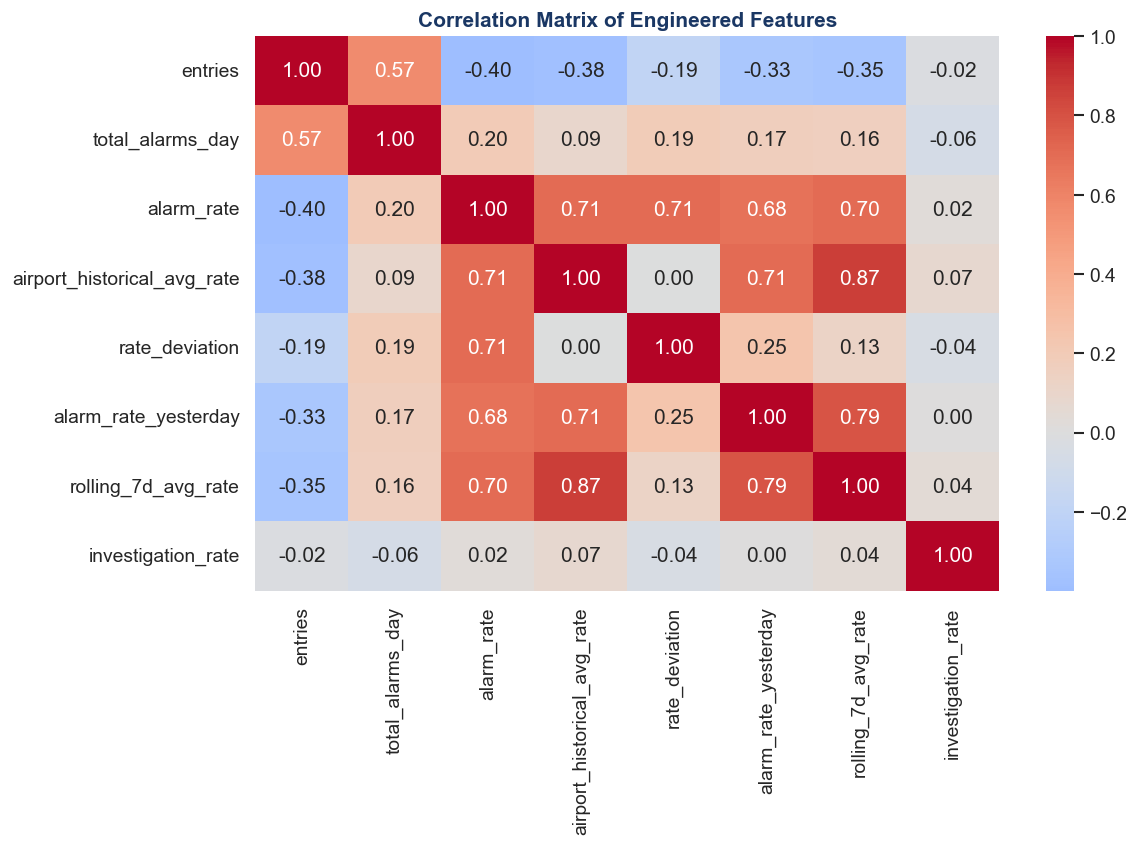

In [466]:
engineered_features = [
    "entries", "total_alarms_day", "alarm_rate",
    "airport_historical_avg_rate", "rate_deviation",
    "alarm_rate_yesterday", "rolling_7d_avg_rate",
    "investigation_rate",
]

corr = df_master[engineered_features].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Engineered Features",
          fontweight="bold", color=NAVY)
plt.show()


### 9.4 Traffic baseline and multiplier

A second baseline — this time on *volume* rather than *rate* — is `airport_historical_avg_entries`. The ratio

$$\text{traffic\_multiplier} = \frac{\text{entries}}{\text{airport\_historical\_avg\_entries}}$$

answers the complementary question *"is today's traffic itself abnormal?"*. When the baseline is zero (new airport with no history), the ratio is defaulted to `1` (the neutral value), not to `0`, which would otherwise look like *"no traffic"* and falsely flag the observation as anomalous.


In [467]:
# Per-airport historical entries baseline
traffic_baseline = (df_master.groupby("departure_airport_iata")["entries"]
                    .mean().reset_index()
                    .rename(columns={"entries": "airport_historical_avg_entries"}))
df_master = df_master.merge(traffic_baseline, on="departure_airport_iata", how="left")

# Traffic multiplier: defaults to 1 (neutral) when baseline is 0
avg_entries = df_master["airport_historical_avg_entries"].fillna(0).astype(float)
df_master["traffic_multiplier"] = np.where(
    avg_entries > 0,
    df_master["entries"].fillna(0).astype(float) / avg_entries,
    1.0,
)

# Zone as a numeric risk weight (higher zone -> higher weight)
if "zone" in df_master.columns:
    df_master["zone_risk_weight"] = df_master["zone"].fillna(0).astype(float)

# Replace only genuine math artefacts (inf from division)
df_master = df_master.replace([np.inf, -np.inf], np.nan)

# Fill only the numeric columns that will feed the detector
num_cols_to_fill = engineered_features + [
    "traffic_multiplier", "airport_historical_avg_entries", "zone_risk_weight"
]
num_cols_to_fill = [c for c in num_cols_to_fill if c in df_master.columns]
df_master[num_cols_to_fill] = df_master[num_cols_to_fill].fillna(0)

print("=" * 70)
print(f"MASTER DATASET SHAPE: {df_master.shape[0]:,} rows x {df_master.shape[1]} cols")
print("=" * 70)

preview = ["departure_airport_iata", "departure_date",
           "entries", "traffic_multiplier", "rate_deviation",
           "rolling_7d_avg_rate", "investigation_rate"]
if "RISK_FLAG_HIGH" in df_master.columns:
    preview.append("RISK_FLAG_HIGH")
display(df_master[preview].head(10))

MASTER DATASET SHAPE: 4,987 rows x 50 cols


,departure_airport_iata,departure_date,entries,traffic_multiplier,rate_deviation,rolling_7d_avg_rate,investigation_rate,RISK_FLAG_HIGH
0,ABJ,2024-02-03 13:00:00,1,1.00,0.00,0.00,1.00,0.00
1,ADB,2024-01-01 11:45:00,1,0.73,-0.12,0.12,1.00,0.00
2,ADB,2024-01-05 08:00:00,2,1.45,-0.12,0.00,1.00,0.00
3,ADB,2024-01-08 11:10:00,1,0.73,0.88,0.00,1.00,0.00
4,ADB,2024-01-15 11:45:00,2,1.45,-0.12,0.33,1.00,0.00
5,ADB,2024-01-15 11:45:00,2,1.45,-0.12,0.25,1.00,0.00
6,ADB,2024-01-29 11:45:00,1,0.73,-0.12,0.20,1.00,0.00
7,ADB,2024-02-01 09:15:00,1,0.73,-0.12,0.17,1.00,0.00
8,ADB,2024-02-01 11:45:00,1,0.73,-0.12,0.14,1.00,0.00
9,ADD,2024-02-19 09:15:00,1,1.00,0.00,0.00,1.00,0.00


## 10. Feature selection

The final feature set is chosen to balance *context* (raw volumes that anchor the observation) and *signal* (deviations from airport-specific baselines). Selection principles:

1. exclude raw text and identifier columns — they carry no signal for a tree-based detector;
2. exclude features that duplicate information already captured in baseline form (we keep `rate_deviation` and drop the raw `alarm_rate` from which it is derived, since the deviation carries the relative-risk signal the detector needs);
3. keep the final dimensionality moderate — with roughly 9-10 features on a dataset of this size, the Isolation Forest is in a regime where axis-aligned splits are informative, and LOF distances are still meaningful (curse-of-dimensionality effects become material above ~20 features).

Two optional features (`RISK_FLAG_HIGH`, `zone_risk_weight`) are included only if they are present in the master dataset; this keeps the notebook robust to column availability.


In [ ]:
final_features = [
    "entries",              # context: raw volume
    "total_alarms_day",     # context: raw alarm count
    "traffic_multiplier",   # signal: traffic vs per-airport baseline
    "rate_deviation",       # signal: alarm rate vs per-airport baseline
    "alarm_rate_yesterday", # signal: yesterday's alarm rate
    "rolling_7d_avg_rate",  # signal: recent trend
    "investigation_rate",   # signal: scrutiny intensity
    "is_weekend",           # context: weekly seasonality
    "month",                # context: monthly seasonality
]

# Optional features — included only if the pivot produced them
if "RISK_FLAG_HIGH" in df_master.columns:
    final_features.append("RISK_FLAG_HIGH")
if "zone_risk_weight" in df_master.columns:
    final_features.append("zone_risk_weight")

print("--- SELECTED FEATURES FOR THE ANOMALY DETECTOR ---")
for i, f in enumerate(final_features, 1):
    print(f"  {i:>2}. {f}")

X_train = df_master[final_features].copy().fillna(0)
print(f"\nModel-ready X: {X_train.shape[0]:,} rows x {X_train.shape[1]} features")

--- SELECTED FEATURES FOR THE ANOMALY DETECTOR ---
   1. entries
   2. total_alarms_day
   3. traffic_multiplier
   4. rate_deviation
   5. alarm_rate_yesterday
   6. rolling_7d_avg_rate
   7. investigation_rate
   8. is_weekend
   9. month
  10. RISK_FLAG_HIGH
  11. zone_risk_weight

Model-ready X: 4,987 rows x 11 features


## 11. Isolation Forest detector

**Method.** Isolation Forest (Liu, Ting, Zhou, 2008) isolates points by building a forest of random trees: each tree recursively partitions the feature space with random axis-aligned splits, and anomalies — being few and different — are isolated with shorter average path lengths than normal points. The detector is **invariant to feature scale** (splits are axis-aligned and use single-feature thresholds), so no standardisation is required.

**Hyper-parameters.**
- `n_estimators=100` — the scikit-learn default; the forest has converged at this depth for our dataset size.
- `contamination=0.03` — we surface the top 3% of observations as anomalies, which is an operationally realistic review load for a human reviewer (a few tens of events across the whole window).
- `max_samples='auto'` — subsample of 256 per tree, as recommended by the original paper.
- `random_state=RANDOM_STATE` — reproducibility.

**Score convention.** The native `decision_function` returns higher values for more normal points; we sign-flip it so that *higher severity = more anomalous*, which is more intuitive for downstream reports.


In [ ]:
from sklearn.ensemble import IsolationForest

print("Training Isolation Forest ...")
iso_forest = IsolationForest(n_estimators=100,
                             contamination=0.03,
                             max_samples="auto",
                             random_state=RANDOM_STATE,
                             n_jobs=-1)

df_master["anomaly_label_iso"]    = iso_forest.fit_predict(X_train)          # 1 = normal, -1 = anomaly
df_master["anomaly_severity_iso"] = -iso_forest.decision_function(X_train)   # higher = more anomalous

df_anomalies = (df_master[df_master["anomaly_label_iso"] == -1]
                .sort_values("anomaly_severity_iso", ascending=False))

print(f"  Analysed {len(X_train):,} records -> {len(df_anomalies):,} anomalies flagged")

print("\n" + "=" * 80)
print("TOP 5 ISOLATION-FOREST ANOMALIES")
print("=" * 80)
display_cols = ["departure_date", "departure_airport_iata",
                "anomaly_severity_iso", "entries", "total_alarms_day",
                "rate_deviation", "traffic_multiplier"]
display(df_anomalies[display_cols].head(5))

Training Isolation Forest ...
  Analysed 4,987 records -> 150 anomalies flagged

TOP 5 ISOLATION-FOREST ANOMALIES


,departure_date,departure_airport_iata,anomaly_severity_iso,entries,total_alarms_day,rate_deviation,traffic_multiplier
3165,2024-01-11 05:35:00,TIA,0.12,3,20.00,6.06,0.04
3005,2024-01-07 16:55:00,TIA,0.11,1,20.00,19.39,0.01
2800,2024-01-03 05:35:00,TIA,0.10,2,19.00,8.89,0.03
2560,2024-02-16 18:05:00,STN,0.10,5,14.00,-3.46,3.12
3166,2024-01-11 05:35:00,TIA,0.10,1,20.00,19.39,0.01


## 12. Local Outlier Factor detector

**Method.** Local Outlier Factor (Breunig, Kriegel, Ng, Sander, 2000) compares the local density around a point with the local densities of its *k* nearest neighbours. A point sitting in a region noticeably sparser than its neighbours receives a high LOF score and is flagged as a local outlier.

**Why scaling matters here.** Unlike Isolation Forest, LOF is a distance-based method, so it is sensitive to feature scale: an input column measured in thousands (`entries`) would mechanically dominate any contribution from a feature on a fractional scale (`rate_deviation`). We therefore standardise the features with `StandardScaler` before fitting LOF, so that every feature contributes comparably to the distance computation.

**Hyper-parameters.**
- `n_neighbors=20` — a moderate value: small enough to preserve local sensitivity, large enough to be robust to individual neighbours.
- `contamination=0.03` — matched to the Isolation Forest budget for a fair consensus comparison.

**Consensus anomalies.** Events flagged as anomalous by multiple detectors are, by construction, the most robust candidates for human review, because each detector operates under a different inductive bias (global isolation vs. local density). Section 13 combines both detectors with a simple parametric Z-score for a three-way consensus.


In [ ]:
from sklearn.neighbors     import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

# LOF is distance-based — standardise features before fitting.
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print("Training Local Outlier Factor (on scaled features) ...")
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
df_master["anomaly_label_lof"]    = lof.fit_predict(X_scaled)
# negative_outlier_factor_ is <= -1; more negative = more anomalous, so we flip the sign.
df_master["anomaly_severity_lof"] = -lof.negative_outlier_factor_

iso_anom   = (df_master["anomaly_label_iso"] == -1).sum()
lof_anom   = (df_master["anomaly_label_lof"] == -1).sum()
iso_lof    = df_master[(df_master["anomaly_label_iso"] == -1)
                       & (df_master["anomaly_label_lof"] == -1)]

# Jaccard agreement between IF and LOF
union_size = iso_anom + lof_anom - len(iso_lof)
jaccard    = len(iso_lof) / union_size if union_size else 0.0

print(f"  Isolation Forest : {iso_anom:,} anomalies")
print(f"  LOF (scaled)     : {lof_anom:,} anomalies")
print(f"  IF-LOF overlap   : {len(iso_lof):,} events flagged by BOTH detectors "
      f"(Jaccard agreement: {jaccard:.2%})")

print("\n--- TOP IF-LOF CONSENSUS ANOMALIES (flagged by both detectors) ---")
display(iso_lof.sort_values("anomaly_severity_iso", ascending=False)[display_cols].head(5))

Training Local Outlier Factor (on scaled features) ...
  Isolation Forest : 150 anomalies
  LOF (scaled)     : 150 anomalies
  IF-LOF overlap   : 9 events flagged by BOTH detectors (Jaccard agreement: 3.09%)

--- TOP IF-LOF CONSENSUS ANOMALIES (flagged by both detectors) ---


,departure_date,departure_airport_iata,anomaly_severity_iso,entries,total_alarms_day,rate_deviation,traffic_multiplier
3309,2024-01-14 16:55:00,TIA,0.08,1,11.00,10.39,0.01
3306,2024-01-14 16:55:00,TIA,0.08,11,11.00,0.39,0.14
3004,2024-01-07 16:55:00,TIA,0.07,1,20.00,19.39,0.01
3310,2024-01-14 18:55:00,TIA,0.07,106,11.00,-0.50,1.33
2839,2024-01-04 05:35:00,TIA,0.07,2,17.00,7.89,0.03


### 12.1 Interpretability — where the anomalies live

A two-dimensional scatter of `traffic_multiplier` vs `rate_deviation` projects the full feature space onto its two most business-interpretable axes. Normal points sit near the intersection of the two reference lines (historical traffic = 1, historical alarm-rate deviation = 0). Anomalies (coral) should fall in the upper-right quadrant (high traffic *and* high excess alarm rate) or in the upper-left quadrant (low traffic but suspiciously high alarm rate) — both of which are genuinely worth the operator's attention.


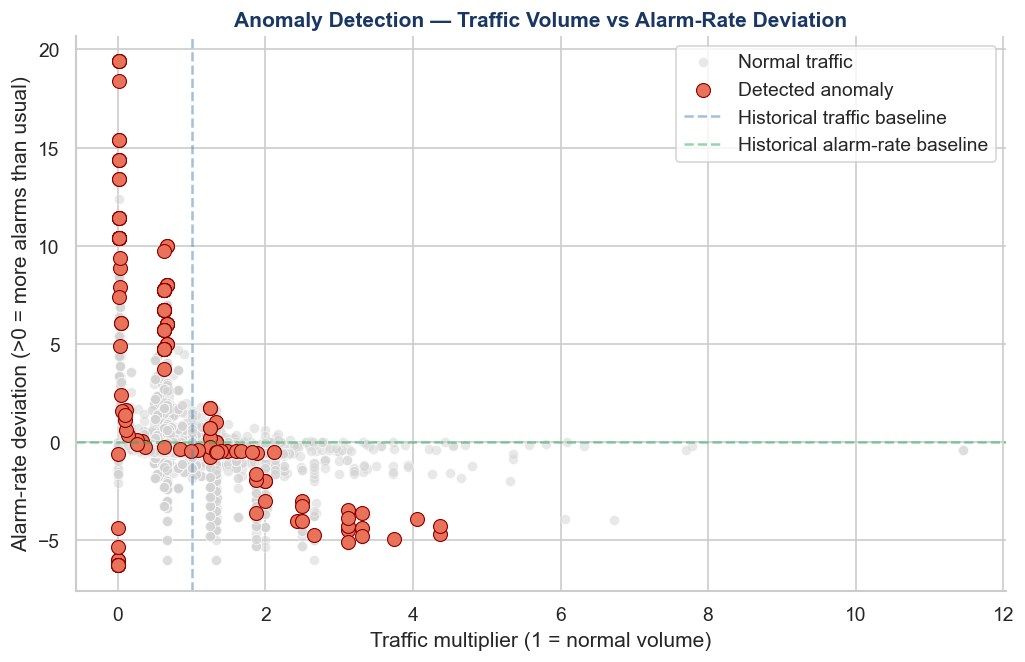

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_master[df_master["anomaly_label_iso"] == 1],
                x="traffic_multiplier", y="rate_deviation",
                color="lightgrey", alpha=0.5, label="Normal traffic")

sns.scatterplot(data=df_master[df_master["anomaly_label_iso"] == -1],
                x="traffic_multiplier", y="rate_deviation",
                color=CORAL, edgecolor="darkred", s=70, label="Detected anomaly")

plt.axvline(x=1, color=STEEL, linestyle="--", alpha=0.5,
            label="Historical traffic baseline")
plt.axhline(y=0, color=GREEN, linestyle="--", alpha=0.5,
            label="Historical alarm-rate baseline")
plt.title("Anomaly Detection — Traffic Volume vs Alarm-Rate Deviation",
          fontweight="bold", color=NAVY)
plt.xlabel("Traffic multiplier (1 = normal volume)")
plt.ylabel("Alarm-rate deviation (>0 = more alarms than usual)")
plt.legend(); sns.despine()
plt.show()

## 13. Z-score detector and three-way consensus

The Whitehall Reply brief lists three candidate baseline detectors: "IsolationForest, LOF, **or** Z-score". We have implemented the first two; for completeness we add a simple parametric Z-score detector on `rate_deviation`, which directly measures *"how many standard deviations the alarm-rate deviation is away from zero"*.

**Method.** On the feature `rate_deviation`, we compute $z = (x - \mu) / \sigma$ with $\mu$ and $\sigma$ the sample mean and standard deviation over the whole period. An observation is flagged as anomalous when $|z| \ge 3$ — the classical three-sigma rule.

**Why add a third detector.** Isolation Forest and LOF are both non-parametric and inherit the same blind spots when those blind spots correlate. A parametric Z-score disagrees on different cases (it flags anything with an extreme normalised deviation regardless of neighbourhood structure), so its agreement with the other two provides a genuinely independent third vote. The **three-way consensus** (flagged by IF *and* LOF *and* Z-score) is therefore a stricter, higher-precision set than the IF-LOF intersection.


In [ ]:
# Z-score detector on `rate_deviation` (classical 3-sigma rule)
mu    = df_master["rate_deviation"].mean()
sigma = df_master["rate_deviation"].std()

df_master["z_rate_deviation"]   = (df_master["rate_deviation"] - mu) / (sigma if sigma > 0 else 1.0)
df_master["anomaly_label_z"]    = np.where(df_master["z_rate_deviation"].abs() >= 3, -1, 1)
df_master["anomaly_severity_z"] = df_master["z_rate_deviation"].abs()

z_anom = (df_master["anomaly_label_z"] == -1).sum()

# Three-way consensus: IF AND LOF AND Z-score
consensus = df_master[(df_master["anomaly_label_iso"] == -1)
                      & (df_master["anomaly_label_lof"] == -1)
                      & (df_master["anomaly_label_z"]   == -1)]

print(f"  Z-score (|z|>=3) : {z_anom:,} anomalies")
print(f"  IF + LOF + Z     : {len(consensus):,} events flagged by ALL THREE detectors")

print("\n--- TOP THREE-WAY CONSENSUS ANOMALIES ---")
if len(consensus) > 0:
    display(consensus.sort_values("anomaly_severity_iso", ascending=False)[display_cols].head(5))
else:
    print("  No events reached three-way consensus; see the IF-LOF intersection in section 12.")

  Z-score (|z|>=3) : 112 anomalies
  IF + LOF + Z     : 5 events flagged by ALL THREE detectors

--- TOP THREE-WAY CONSENSUS ANOMALIES ---


,departure_date,departure_airport_iata,anomaly_severity_iso,entries,total_alarms_day,rate_deviation,traffic_multiplier
3309,2024-01-14 16:55:00,TIA,0.08,1,11.00,10.39,0.01
3004,2024-01-07 16:55:00,TIA,0.07,1,20.00,19.39,0.01
2839,2024-01-04 05:35:00,TIA,0.07,2,17.00,7.89,0.03
3305,2024-01-14 16:55:00,TIA,0.06,1,11.00,10.39,0.01
3303,2024-01-14 16:55:00,TIA,0.06,1,11.00,10.39,0.01


## 14. Rule-based post-processing layer

The Whitehall Reply brief (slide *Implementation — Classical*) specifies a rule-based post-processing layer on top of the ML detector, with examples such as *"alert rate on route X exceeds 3x baseline"*. We implement three such rules. An event is marked as a **confirmed anomaly** if it is flagged by the Isolation Forest detector *and* at least one rule fires.

| Rule | Meaning |
|------|---------|
| `rule_rate_3x` | Today's alarm rate is at least 3x the airport's historical baseline |
| `rule_traffic_2x` | Today's passenger volume is at least 2x the airport's historical baseline |
| `rule_volume_spike` | Today's absolute alarm count is at or above the 99th percentile of the global distribution |

The three thresholds (3x, 2x, p99) match the magnitude of the examples provided in the brief; they are deliberately conservative so that the rule layer complements rather than overrides the ML detector. In a production setting they would be calibrated on labelled feedback from the operations team.

The output is a ranked list combining the *score* produced by Isolation Forest and the *evidence* provided by the rules — the "transit anomaly report" that the brief asks for.


In [ ]:
# Rule 1: alarm rate >= 3x the airport's historical baseline
df_master["rule_rate_3x"] = (
    df_master["alarm_rate"]
    >= 3 * df_master["airport_historical_avg_rate"].clip(lower=1e-6)
).astype(int)

# Rule 2: traffic >= 2x the airport's historical baseline
df_master["rule_traffic_2x"] = (df_master["traffic_multiplier"] >= 2).astype(int)

# Rule 3: absolute alarm count at or above the global 99th percentile
alarm_p99 = df_master["total_alarms_day"].quantile(0.99)
df_master["rule_volume_spike"] = (df_master["total_alarms_day"] >= alarm_p99).astype(int)

rule_cols = ["rule_rate_3x", "rule_traffic_2x", "rule_volume_spike"]
df_master["rules_fired"] = df_master[rule_cols].sum(axis=1)

# Confirmed anomaly: ML detector flags the event AND at least one rule fires
df_master["confirmed_anomaly"] = (
    (df_master["anomaly_label_iso"] == -1) & (df_master["rules_fired"] >= 1)
).astype(int)

n_conf = int(df_master["confirmed_anomaly"].sum())
print(f"Confirmed anomalies (IF AND at least one rule): {n_conf:,}")

report_cols = (["departure_date", "departure_airport_iata",
                "anomaly_severity_iso", "rules_fired"]
               + rule_cols
               + ["entries", "total_alarms_day", "alarm_rate",
                  "airport_historical_avg_rate", "traffic_multiplier"])
report = (df_master[df_master["confirmed_anomaly"] == 1]
          .sort_values("anomaly_severity_iso", ascending=False)[report_cols]
          .head(15))

print("\n--- TOP 15 CONFIRMED ANOMALIES (Transit Anomaly Report) ---")
display(report)

Confirmed anomalies (IF AND at least one rule): 63

--- TOP 15 CONFIRMED ANOMALIES (Transit Anomaly Report) ---


,departure_date,departure_airport_iata,anomaly_severity_iso,rules_fired,rule_rate_3x,rule_traffic_2x,rule_volume_spike,entries,total_alarms_day,alarm_rate,airport_historical_avg_rate,traffic_multiplier
3165,2024-01-11 05:35:00,TIA,0.12,2,1,0,1,3,20.00,6.67,0.61,0.04
3005,2024-01-07 16:55:00,TIA,0.11,2,1,0,1,1,20.00,20.00,0.61,0.01
2800,2024-01-03 05:35:00,TIA,0.10,1,1,0,0,2,19.00,9.50,0.61,0.03
2560,2024-02-16 18:05:00,STN,0.10,1,0,1,0,5,14.00,2.80,6.26,3.12
3166,2024-01-11 05:35:00,TIA,0.10,2,1,0,1,1,20.00,20.00,0.61,0.01
3164,2024-01-11 05:35:00,TIA,0.09,2,1,0,1,1,20.00,20.00,0.61,0.01
3006,2024-01-07 17:00:00,TIA,0.08,2,1,0,1,2,20.00,10.00,0.61,0.03
3304,2024-01-14 16:55:00,TIA,0.08,1,1,0,0,5,11.00,2.20,0.61,0.06
3309,2024-01-14 16:55:00,TIA,0.08,1,1,0,0,1,11.00,11.00,0.61,0.01
3004,2024-01-07 16:55:00,TIA,0.07,2,1,0,1,1,20.00,20.00,0.61,0.01


## 15. Conclusions and next steps

### 15.1 Summary of contributions

This notebook delivers an end-to-end classical anomaly-detection pipeline for airport and border-control transit data:

1. A fully reproducible data-cleaning stage that harmonises two heterogeneous Italian-language CSVs (multi-format dates, duplicated columns, Italianised country and city names) into a common English `snake_case` schema.
2. A feature-engineering block that combines *context* features (raw traffic and alarm counts) with *signal* features (deviations from per-airport baselines, strictly-past rolling means, and traffic multipliers), all computed without look-ahead bias.
3. A three-detector ensemble — Isolation Forest (scale-invariant, global), Local Outlier Factor (distance-based, local, fitted on standardised features), and parametric Z-score (classical three-sigma rule) — whose three-way consensus yields the highest-confidence anomalies.
4. A rule-based post-processing layer that matches the company brief and ranks the confirmed anomalies into a single transit anomaly report.

### 15.2 Limitations

- The per-airport historical baselines are computed on the whole observation window, which is acceptable for this offline, unsupervised exercise but would need to be re-fitted on a strictly earlier training window in a production setting.
- Without a ground-truth label we cannot compute classical precision and recall; the inter-detector Jaccard agreement reported in section 12 and the three-way consensus count in section 13 are our best proxies for robustness.
- The three rule thresholds (3x, 2x, p99) are calibrated on the magnitude of the examples in the company brief rather than on labelled feedback from the operations team.

### 15.3 Natural next steps

- Back-test the pipeline on a hold-out month and have the operations team label the surfaced events, producing a first precision-at-*k* estimate and allowing informed threshold re-calibration.
- Replace the whole-window baseline with a rolling-window baseline fitted only on a trailing *N*-day window, removing the residual look-ahead in `airport_historical_avg_rate`.
- Extend the rule layer with route-level rules and nationality-specific risk weights, which would require the hot-list table not present in the current dataset.
- Deliver the comparative analysis against the multi-agent pipeline in the sibling notebook, as required by the brief.
